In [1]:
import sys
sys.path.insert(0, '/home/bnc2119/MEDAL')
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from src.medal.eval_utils import load_and_split, get_teacher_embeddings
from src.medal.core import AutoEncoder
import torch
import matplotlib.colors as mcolors
from pathlib import Path
import matplotlib.ticker as ticker
from sklearn.model_selection import train_test_split
from sklearn.metrics import jaccard_score
PATH_PREFIX = '/share/ctn/users/bnc2119' 
%load_ext autoreload
%autoreload 2

/home/bnc2119/.conda/envs/medal/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-03-29 11:37:10,531	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
2026-03-29 11:37:11,417	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


In [2]:
def load_trained_ae(ckpt_path, input_dim, hidden_dims,activation=torch.nn.SELU, latent_dim=2, batchnorm=False):
    import sys, os
    old_stdout = sys.stdout
    sys.stdout = open(os.devnull, "w")
    model = AutoEncoder(
        input_dim=input_dim,
        latent_dim=latent_dim,
        hidden_dims=hidden_dims,
        activation=activation,            
        bottleneck_activation=None,
        use_batchnorm = batchnorm
    )
    sys.stdout = old_stdout

    sd = torch.load(ckpt_path, map_location="cpu")

    # unwrap to the real state dict
    if isinstance(sd, dict) and "model" in sd and isinstance(sd["model"], dict):
        sd = sd["model"]
    elif isinstance(sd, dict) and "state_dict" in sd and isinstance(sd["state_dict"], dict):
        sd = sd["state_dict"]

    # remove DDP prefixes if any
    sd = {k.replace("module.", ""): v for k, v in sd.items()}

    # load STRICTLY so we fail fast if something doesn’t match
    missing, unexpected = model.load_state_dict(sd, strict=False)
    print(f"loaded params: {len(sd)} | missing={len(missing)} | unexpected={len(unexpected)}")
    if missing or unexpected:
        print("⚠️ Check architecture/keys. Example missing:", missing[:3], "unexpected:", unexpected[:3])

    model.eval()
    return model

def split_scdeed_labels(df, best_param):
    result = []
    for l in ["dubious", "trustworthy", "intermediate"]:
        vec = df.loc[best_param, f"{l}_cells"]
        if vec == 'none':
            continue
        ls_indices = np.array(vec.split(',')).astype(int)
        result.extend(list(zip([l]* len(ls_indices), ls_indices)))
    return pd.DataFrame(result, columns = ['label', 'index']).set_index('index').sort_index()

import numpy as np

def jaccard_curve(scores_runs, quantiles):

    jaccard_curve = []
    core_curve = []

    for q in quantiles:
        threshold_sets = [scores_runs[s] >= np.quantile(scores_runs[s], q) for s in scores_runs]

        inter = np.logical_and.reduce(threshold_sets).sum()
        union = np.logical_or.reduce(threshold_sets).sum()
        set_sizes = np.array([x.sum() for x in threshold_sets], dtype=float)
        mean_set_size = set_sizes.mean()

        print(f"q={q:0.3f}, inter={inter}, union={union}, mean_set_size={mean_set_size:.1f}")

        j3 = inter / union if union > 0 else 0.0
        core = inter / mean_set_size if mean_set_size > 0 else 0.0

        jaccard_curve.append(j3)
        core_curve.append(core)

    return np.array(jaccard_curve), np.array(core_curve)

In [3]:
from itertools import combinations
from scipy.stats import spearmanr
# ---------------------------
# Pairwise Spearman rank correlation across runs
# ---------------------------
def summarize_rank_correlation(score_dict):
    """
    score_dict format:
      score_dict[hyperparam][seed] = 1D np.ndarray of scores
    """
    rows = []

    for hp, seed_to_scores in score_dict.items():
        available_seeds = sorted(seed_to_scores.keys())
        for s1, s2 in combinations(available_seeds, 2):
            rho, pval = spearmanr(seed_to_scores[s1], seed_to_scores[s2])
            rows.append({
                "hyperparam": hp,
                "seed1": s1,
                "seed2": s2,
                "spearman_rho": rho,
                "spearman_pval": pval
            })

    pairwise_df = pd.DataFrame(rows)

    summary_df = (
        pairwise_df
        .groupby("hyperparam", as_index=False)["spearman_rho"]
        .agg(["mean", "std", "count"])
        .reset_index()
        .rename(columns={
            "mean": "mean_pairwise_spearman",
            "std": "std_pairwise_spearman",
            "count": "n_pairs"
        })
    )

    return pairwise_df, summary_df

## MNIST

In [112]:
X_og, X_test, y_og, y_test = load_and_split("mnist", test_size=0.2, seed=0, labels=True)
X, X_val, y, y_val = train_test_split(X_og, y_og, test_size=0.2, random_state=0)
label_colors = [plt.get_cmap("tab20")(i) for i in range(10)]
mnist_palette = {digit: col for digit, col in zip(y.value_counts().index, label_colors)}
cmap = sns.color_palette("BuGn", as_cmap=True)

In [5]:
tsne_param_sweep = [    5,    11,    27,    62,   146,   341,   793,  1846]
per_sample_recon_medal_all_tsne = {perp: {} for perp in tsne_param_sweep}
per_sample_recon_scdeed_all_tsne = {perp: {} for perp in tsne_param_sweep}
per_sample_recon_embedr_all_tsne = {perp: {} for perp in tsne_param_sweep}
per_sample_recon_pcs_all_tsne = {perp: {} for perp in tsne_param_sweep}
for s in [0, 2, 10]:
    pcs_df = pd.read_csv(Path(PATH_PREFIX) / f'MEDAL/comparisons/results_pcs_seed{s}/mnist_train/scores_per_point_all_perplexities.csv', index_col=0)
    scdeed_df = pd.read_csv(Path(PATH_PREFIX) / f"MEDAL/comparisons/results_scdeed_tsne/seed{s}/tsne_best_mnist_train_full_results.csv", index_col=0)
    embedr_df = pd.read_csv(Path(PATH_PREFIX) / f'MEDAL/comparisons/results_embedr_tsne_seed{s}/mnist_train/scores_per_point_all_perplexities.csv', index_col=0)
    for perp in tsne_param_sweep:
        teacher_embed = np.load(Path(PATH_PREFIX) / f"drd_data/embeddings2/mnist_tsne_{perp}_{s}_train.npy")
        student = load_trained_ae(Path(PATH_PREFIX) / f"drd_data/tmp_results/chkpt_teacher_seed/mnist/medal_tsne2_{perp}_tc5_{s}_ckpts/final.pt",
                input_dim=784,
                hidden_dims=[512, 512, 512, 512],
                latent_dim=2, activation=torch.nn.SELU, batchnorm=False)
        
        student_recon, student_embed = student(torch.tensor(X, dtype=torch.float32))
        train_distill = np.mean((teacher_embed - student_embed.detach().numpy()) ** 2)
        if train_distill < 1e-5:
            per_sample_recon = np.mean((student_recon.detach().numpy() - X)**2, axis=1)
            per_sample_recon_medal_all_tsne[perp][s] = per_sample_recon
        
        per_sample_scdeed = split_scdeed_labels(scdeed_df, perp)['label']
        per_sample_recon_scdeed_all_tsne[perp][s] = per_sample_scdeed == "dubious"
        per_sample_embedr = embedr_df.loc[perp, 'embedr_pval']
        per_sample_recon_embedr_all_tsne[perp][s] = per_sample_embedr
        per_sample_pcs = pcs_df.loc[perp, 'sscore']
        per_sample_recon_pcs_all_tsne[perp][s] = per_sample_pcs
    

/tmp/ipykernel_21037/1041672765.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sd = torch.load(ckpt_path, map_location="cpu")


loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0


/tmp/ipykernel_21037/1041672765.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sd = torch.load(ckpt_path, map_location="cpu")


loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0


/tmp/ipykernel_21037/1041672765.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sd = torch.load(ckpt_path, map_location="cpu")


loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0


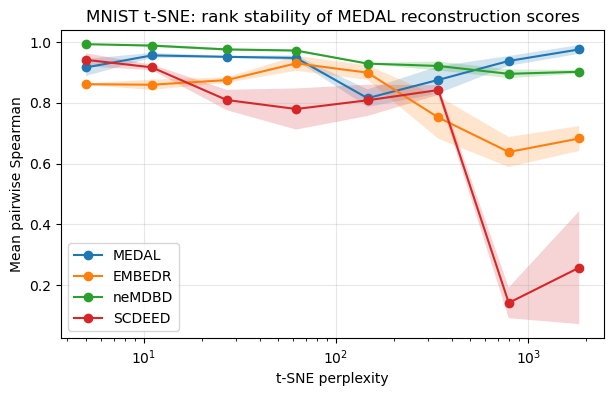

In [6]:
medal_pairwise_spearman_df, medal_mean_spearman_by_perp = summarize_rank_correlation(
    per_sample_recon_medal_all_tsne
)
embedr_pairwise_spearman_df, embedr_mean_spearman_by_perp = summarize_rank_correlation(
    per_sample_recon_embedr_all_tsne
)

pcs_pairwise_spearman_df, pcs_mean_spearman_by_perp = summarize_rank_correlation(
    per_sample_recon_pcs_all_tsne
)
scdeed_pairwise_spearman_df, scdeed_mean_spearman_by_perp = summarize_rank_correlation(
    per_sample_recon_scdeed_all_tsne
)

plt.figure(figsize=(7, 4))
plt.plot(
    medal_mean_spearman_by_perp["hyperparam"],
    medal_mean_spearman_by_perp["mean_pairwise_spearman"],
    marker="o", label = 'MEDAL'
)
plt.plot(
    embedr_mean_spearman_by_perp["hyperparam"],
    embedr_mean_spearman_by_perp["mean_pairwise_spearman"],
    marker="o", label = 'EMBEDR'
)
plt.plot(
    pcs_mean_spearman_by_perp["hyperparam"],
    pcs_mean_spearman_by_perp["mean_pairwise_spearman"],
    marker="o", label = 'neMDBD'
)
plt.plot(
    scdeed_mean_spearman_by_perp["hyperparam"],
    scdeed_mean_spearman_by_perp["mean_pairwise_spearman"],
    marker="o", label = 'SCDEED'
)

plt.fill_between(
    medal_mean_spearman_by_perp["hyperparam"],
    medal_mean_spearman_by_perp["mean_pairwise_spearman"] - medal_mean_spearman_by_perp["std_pairwise_spearman"].fillna(0),
    medal_mean_spearman_by_perp["mean_pairwise_spearman"] + medal_mean_spearman_by_perp["std_pairwise_spearman"].fillna(0),
    alpha=0.2
)
plt.fill_between(
    embedr_mean_spearman_by_perp["hyperparam"],
    embedr_mean_spearman_by_perp["mean_pairwise_spearman"] - embedr_mean_spearman_by_perp["std_pairwise_spearman"].fillna(0),
    embedr_mean_spearman_by_perp["mean_pairwise_spearman"] + embedr_mean_spearman_by_perp["std_pairwise_spearman"].fillna(0),
    alpha=0.2
)
plt.fill_between(
    pcs_mean_spearman_by_perp["hyperparam"],
    pcs_mean_spearman_by_perp["mean_pairwise_spearman"] - pcs_mean_spearman_by_perp["std_pairwise_spearman"].fillna(0),
    pcs_mean_spearman_by_perp["mean_pairwise_spearman"] + pcs_mean_spearman_by_perp["std_pairwise_spearman"].fillna(0),
    alpha=0.2
)
plt.fill_between(
    scdeed_mean_spearman_by_perp["hyperparam"],
    scdeed_mean_spearman_by_perp["mean_pairwise_spearman"] - scdeed_mean_spearman_by_perp["std_pairwise_spearman"].fillna(0),
    scdeed_mean_spearman_by_perp["mean_pairwise_spearman"] + scdeed_mean_spearman_by_perp["std_pairwise_spearman"].fillna(0),
    alpha=0.2
)
plt.xscale("log")
plt.legend()
plt.xlabel("t-SNE perplexity")
plt.ylabel("Mean pairwise Spearman")
plt.title("MNIST t-SNE: rank stability of MEDAL reconstruction scores")
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
quantiles = np.linspace(0.5, 0.975, 20)
j3_medal_teachers, core_medal_teachers = zip(*[
    jaccard_curve(per_sample_recon_medal_all_tsne[perp], quantiles)
    for perp in tsne_param_sweep
])
j3_medal_teachers = np.array(j3_medal_teachers)
core_medal_teachers = np.array(core_medal_teachers)

j3_embedr_teachers, core_embedr_teachers = zip(*[
    jaccard_curve(per_sample_recon_embedr_all_tsne[perp], quantiles)
    for perp in tsne_param_sweep
])
j3_embedr_teachers = np.array(j3_embedr_teachers)
core_embedr_teachers = np.array(core_embedr_teachers)

j3_pcs_teachers, core_pcs_teachers = zip(*[
    jaccard_curve(per_sample_recon_pcs_all_tsne[perp], quantiles)
    for perp in tsne_param_sweep
])
j3_pcs_teachers = np.array(j3_pcs_teachers)
core_pcs_teachers = np.array(core_pcs_teachers)

j3_scdeed_teachers = [np.logical_and.reduce([per_sample_recon_scdeed_all_tsne[perp][s] for s in [0, 2, 10]]).sum() /
                      np.logical_or.reduce([per_sample_recon_scdeed_all_tsne[perp][s] for s in [0, 2, 10]]).sum()
                     for perp in tsne_param_sweep]

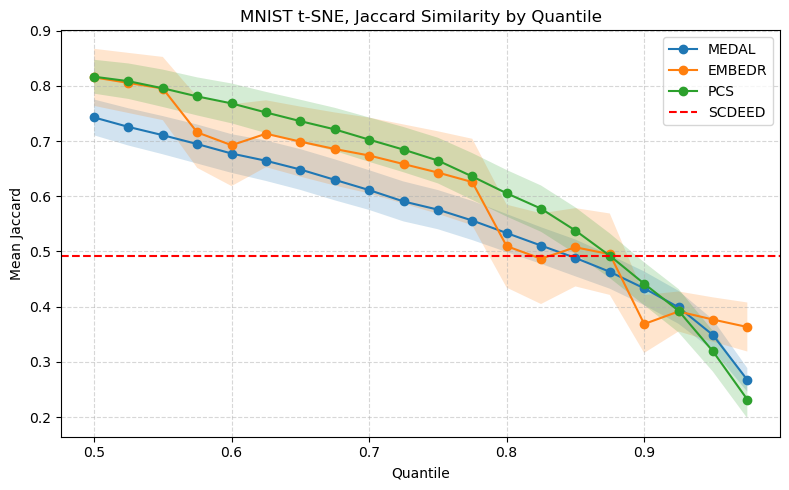

In [8]:
quantiles = np.linspace(0.5, 0.975, 20)

results = {
    "MEDAL": j3_medal_teachers,
    "EMBEDR": j3_embedr_teachers,
    "PCS": j3_pcs_teachers,
}

fig, ax = plt.subplots(figsize=(8, 5))

for label, data in results.items():
    means = data.mean(axis=0)      # (10,)
    se = data.std(axis=0) / np.sqrt(data.shape[0])  # (10,)

    ax.plot(quantiles, means, marker='o', label=label)
    ax.fill_between(quantiles, means - se, means + se, alpha=0.2)

ax.axhline(y=np.mean(j3_scdeed_teachers), color='red', label='SCDEED', ls='--')
ax.set_xlabel("Quantile")
ax.set_ylabel("Mean Jaccard")
ax.set_title("MNIST t-SNE, Jaccard Similarity by Quantile")
ax.legend()
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [9]:
umap_param_sweep = np.unique(np.logspace(np.log10(5), np.log10(500), 15).astype(int))
per_sample_recon_medal_all_umap = {n: {} for n in umap_param_sweep}
per_sample_recon_scdeed_all_umap = {n: {} for n in umap_param_sweep}
per_sample_recon_embedr_all_umap = {n: {} for n in umap_param_sweep}
for s in [0,2, 10]:
    scdeed_df = pd.read_csv(Path(PATH_PREFIX) / f"MEDAL/comparisons/results_scdeed_umap/seed{s}/umap_best_mnist_train_full_results.csv", index_col=0)
    embedr_df = pd.read_csv(Path(PATH_PREFIX) / f'MEDAL/comparisons/results_embedr_umap_seed{s}/mnist_train/scores_per_point_all_n_neighbors.csv', index_col=0)
    for n in umap_param_sweep:
        teacher_embed = np.load(Path(PATH_PREFIX) / f"drd_data/embeddings2/mnist_umap_{n}_0.1_{s}_train.npy")
        student = load_trained_ae(Path(PATH_PREFIX) / f"drd_data/tmp_results/chkpt_teacher_seed/mnist/medal_umap2_{n}_0.1_tc0_{s}_ckpts/final.pt",
                input_dim=784,
                hidden_dims=[512, 512, 512, 512],
                latent_dim=2, activation=torch.nn.SELU, batchnorm=False)
        
        student_recon, student_embed = student(torch.tensor(X, dtype=torch.float32))
        train_distill = np.mean((teacher_embed - student_embed.detach().numpy()) ** 2)
        if train_distill < 1e-5:
            per_sample_recon = np.mean((student_recon.detach().numpy() - X)**2, axis=1)
            per_sample_recon_medal_all_umap[n][s] = per_sample_recon
        
        per_sample_scdeed = split_scdeed_labels(scdeed_df, n)['label']
        per_sample_recon_scdeed_all_umap[n][s] = per_sample_scdeed == "dubious"
        per_sample_embedr = embedr_df.loc[n, 'embedr_pval']
        per_sample_recon_embedr_all_umap[n][s] = per_sample_embedr
    

/tmp/ipykernel_21037/1041672765.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sd = torch.load(ckpt_path, map_location="cpu")


loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0


/tmp/ipykernel_21037/1041672765.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sd = torch.load(ckpt_path, map_location="cpu")


loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0


/tmp/ipykernel_21037/1041672765.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sd = torch.load(ckpt_path, map_location="cpu")


loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0


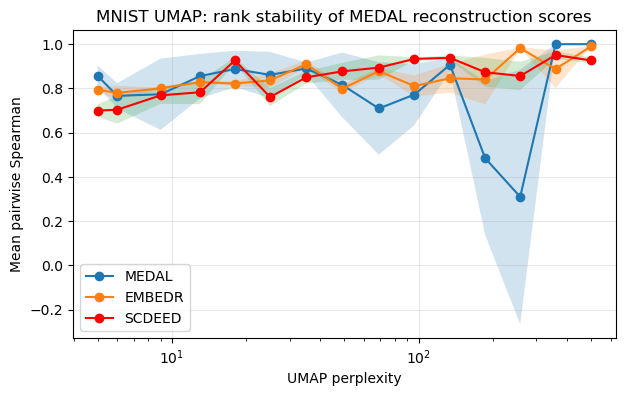

In [10]:
medal_pairwise_spearman_df, medal_mean_spearman_by_perp = summarize_rank_correlation(
    per_sample_recon_medal_all_umap
)
embedr_pairwise_spearman_df, embedr_mean_spearman_by_perp = summarize_rank_correlation(
    per_sample_recon_embedr_all_umap
)
scdeed_pairwise_spearman_df, scdeed_mean_spearman_by_perp = summarize_rank_correlation(
    per_sample_recon_scdeed_all_umap
)

plt.figure(figsize=(7, 4))
plt.plot(
    medal_mean_spearman_by_perp["hyperparam"],
    medal_mean_spearman_by_perp["mean_pairwise_spearman"],
    marker="o", label = 'MEDAL'
)
plt.plot(
    embedr_mean_spearman_by_perp["hyperparam"],
    embedr_mean_spearman_by_perp["mean_pairwise_spearman"],
    marker="o", label = 'EMBEDR'
)
plt.plot(
    scdeed_mean_spearman_by_perp["hyperparam"],
    scdeed_mean_spearman_by_perp["mean_pairwise_spearman"],
    marker="o", label = 'SCDEED', color='red'
)

plt.fill_between(
    medal_mean_spearman_by_perp["hyperparam"],
    medal_mean_spearman_by_perp["mean_pairwise_spearman"] - medal_mean_spearman_by_perp["std_pairwise_spearman"].fillna(0),
    medal_mean_spearman_by_perp["mean_pairwise_spearman"] + medal_mean_spearman_by_perp["std_pairwise_spearman"].fillna(0),
    alpha=0.2
)
plt.fill_between(
    embedr_mean_spearman_by_perp["hyperparam"],
    embedr_mean_spearman_by_perp["mean_pairwise_spearman"] - embedr_mean_spearman_by_perp["std_pairwise_spearman"].fillna(0),
    embedr_mean_spearman_by_perp["mean_pairwise_spearman"] + embedr_mean_spearman_by_perp["std_pairwise_spearman"].fillna(0),
    alpha=0.2
)
plt.fill_between(
    scdeed_mean_spearman_by_perp["hyperparam"],
    scdeed_mean_spearman_by_perp["mean_pairwise_spearman"] - scdeed_mean_spearman_by_perp["std_pairwise_spearman"].fillna(0),
    scdeed_mean_spearman_by_perp["mean_pairwise_spearman"] + scdeed_mean_spearman_by_perp["std_pairwise_spearman"].fillna(0),
    alpha=0.2
)
plt.xscale("log")
plt.legend()
plt.xlabel("UMAP perplexity")
plt.ylabel("Mean pairwise Spearman")
plt.title("MNIST UMAP: rank stability of MEDAL reconstruction scores")
plt.grid(True, alpha=0.3)
plt.show()

In [11]:
quantiles = np.linspace(0.8, 0.975, 20)
j3_medal_teachers, core_medal_teachers = zip(*[
    jaccard_curve(per_sample_recon_medal_all_umap[perp], quantiles)
    for perp in umap_param_sweep
])
j3_medal_teachers = np.array(j3_medal_teachers)
core_medal_teachers = np.array(core_medal_teachers)

j3_embedr_teachers, core_embedr_teachers = zip(*[
    jaccard_curve(per_sample_recon_embedr_all_umap[perp], quantiles)
    for perp in umap_param_sweep
])
j3_embedr_teachers = np.array(j3_embedr_teachers)
core_embedr_teachers = np.array(core_embedr_teachers)

j3_scdeed_teachers = [np.logical_and.reduce([per_sample_recon_scdeed_all_umap[n][s] for s in [0, 2, 10]]).sum() /
                      np.logical_or.reduce([per_sample_recon_scdeed_all_umap[n][s] for s in [0, 2, 10]]).sum()
                     for n in umap_param_sweep]


q=0.800, inter=768, union=1904, mean_set_size=1280.0
q=0.809, inter=718, union=1838, mean_set_size=1221.0
q=0.818, inter=682, union=1756, mean_set_size=1162.0
q=0.828, inter=637, union=1686, mean_set_size=1103.0
q=0.837, inter=597, union=1611, mean_set_size=1045.0
q=0.846, inter=558, union=1529, mean_set_size=986.0
q=0.855, inter=518, union=1456, mean_set_size=927.0
q=0.864, inter=477, union=1366, mean_set_size=868.0
q=0.874, inter=440, union=1284, mean_set_size=809.0
q=0.883, inter=403, union=1191, mean_set_size=750.0
q=0.892, inter=365, union=1103, mean_set_size=691.0
q=0.901, inter=339, union=1017, mean_set_size=632.0
q=0.911, inter=296, union=943, mean_set_size=573.0
q=0.920, inter=261, union=840, mean_set_size=514.0
q=0.929, inter=223, union=754, mean_set_size=455.0
q=0.938, inter=188, union=664, mean_set_size=396.0
q=0.947, inter=148, union=589, mean_set_size=337.0
q=0.957, inter=113, union=486, mean_set_size=278.0
q=0.966, inter=82, union=386, mean_set_size=219.0
q=0.975, inter=

q=0.828, inter=784, union=2273, mean_set_size=1470.3
q=0.837, inter=664, union=2100, mean_set_size=1326.0
q=0.846, inter=664, union=2100, mean_set_size=1326.0
q=0.855, inter=597, union=2028, mean_set_size=1265.3
q=0.864, inter=487, union=1820, mean_set_size=1102.3
q=0.874, inter=487, union=1820, mean_set_size=1102.3
q=0.883, inter=487, union=1820, mean_set_size=1102.3
q=0.892, inter=357, union=1546, mean_set_size=894.0
q=0.901, inter=323, union=1494, mean_set_size=853.7
q=0.911, inter=266, union=1297, mean_set_size=729.7
q=0.920, inter=234, union=1193, mean_set_size=667.7
q=0.929, inter=204, union=1070, mean_set_size=594.3
q=0.938, inter=152, union=923, mean_set_size=499.0
q=0.947, inter=125, union=823, mean_set_size=441.0
q=0.957, inter=94, union=662, mean_set_size=349.3
q=0.966, inter=69, union=543, mean_set_size=274.3
q=0.975, inter=38, union=418, mean_set_size=200.7
q=0.800, inter=885, union=2473, mean_set_size=1618.7
q=0.809, inter=857, union=2444, mean_set_size=1586.3
q=0.818, in

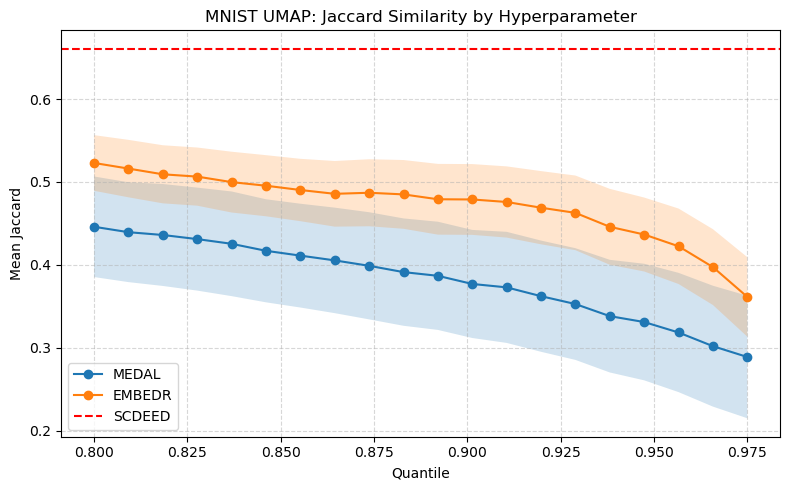

In [12]:
results = {
    "MEDAL": j3_medal_teachers,
    "EMBEDR": j3_embedr_teachers,
}
fig, ax = plt.subplots(figsize=(8, 5))

for label, data in results.items():        
    means = data.mean(axis=0)      
    se = data.std(axis=0) / np.sqrt(data.shape[0])  

    ax.plot(quantiles, means, marker='o', label=label)
    ax.fill_between(quantiles, means - se, means + se, alpha=0.2)

ax.axhline(np.mean(j3_scdeed_teachers), color='red', label='SCDEED', ls='--')
ax.set_xlabel("Quantile")
ax.set_ylabel("Mean Jaccard")
ax.set_title("MNIST UMAP: Jaccard Similarity by Hyperparameter")
ax.legend()
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'MNIST UMAP MEDAL')

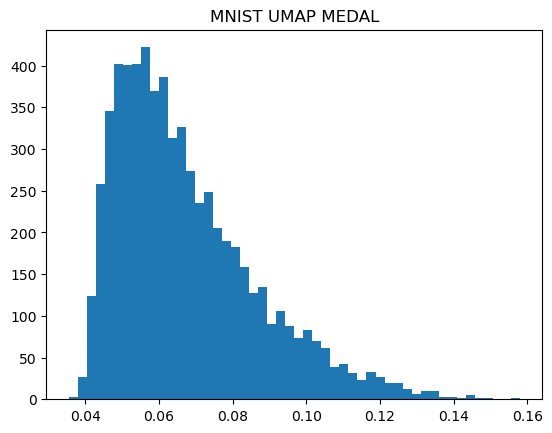

In [13]:
plt.hist(per_sample_recon_medal_all_umap[umap_param_sweep[-2]][0], bins=50)
plt.title("MNIST UMAP MEDAL")

In [14]:
np.quantile(per_sample_recon_embedr_all_umap[umap_param_sweep[-2]][0], 0.95)

np.float64(0.8518874999999999)

## Hydra

In [102]:
X_og, X_test, y_og, y_test = load_and_split("hydra", test_size=0.2, seed=0, labels=True)
X, X_val, y, y_val = train_test_split(X_og, y_og, test_size=0.2, random_state=0)

hydra_palette = color_map = {
    "enEp_tentacle": "#1e3a8a",
    "enEp_stem_cell": "#1d4ed8",
    "enEp_foot": "#2563eb",
    "enEp_head": "#3b82f6",
    "enEp-nb(pd)": "#60a5fa",
    "enEp-nem(pd)": "#93c5fd",
    "enEp_tent-nem(pd)": "#bfdbfe",
    "ecEp-nb(pd)": "#134e4a",
    "ecEp_battery_cell2(mp)": "#0f766e",
    "ecEp_stem_cell": "#0d9488",
    "ecEp_head": "#14b8a6",
    "ecEp-nem(id)": "#2dd4bf",
    "ecEp_basal_disk": "#5eead4",
    "ecEp_battery_cell1(mp)": "#99f6e4",
    "i_stem_cell/progenitor": "#4a044e",
    "i_neuron/gland_cell_progenitor": "#6b21a8",
    "i_neuron_progenitor": "#7e22ce",
    "i_nb1": "#7c2d12",
    "i_nb2": "#c2410c",
    "i_nb3": "#ea580c",
    "i_nb4": "#f97316",
    "i_nb5": "#fb923c",
    "i_neuron_ec1": "#831843",
    "i_neuron_ec2": "#be185d",
    "i_neuron_ec3": "#db2777",
    "i_neuron_ec4": "#ec4899",
    "i_neuron_ec5": "#f472b6",
    "i_neuron_en1": "#3b0764",
    "i_neuron_en2": "#5b21b6",
    "i_neuron_en3": "#7c3aed",
    "i_female_germline1": "#312e81",
    "i_female_germline2_nurse": "#4338ca",
    "i_male_germline": "#818cf8",
    "i_granular_mucous_gland_cell": "#7f1d1d",
    "i_zymogen_gland_cell": "#b91c1c",
    "i_spumous_mucous_gland_cell": "#ef4444",
    "i_nematocyte": "#92400e",
    "db": "#d97706",
}

category_map = {
    "enEp_tentacle": "enEp",
    "enEp_stem_cell": "enEp",
    "enEp_foot": "enEp",
    "enEp_head": "enEp",
    "enEp-nb(pd)": "enEp",
    "enEp-nem(pd)": "enEp",
    "enEp_tent-nem(pd)": "enEp",
    "ecEp-nb(pd)": "ecEp",
    "ecEp_battery_cell2(mp)": "ecEp",
    "ecEp_stem_cell": "ecEp",
    "ecEp_head": "ecEp",
    "ecEp-nem(id)": "ecEp",
    "ecEp_basal_disk": "ecEp",
    "ecEp_battery_cell1(mp)": "ecEp",
    "i_stem_cell/progenitor": "i_progenitors",
    "i_neuron/gland_cell_progenitor": "i_progenitors",
    "i_neuron_progenitor": "i_progenitors",
    "i_nb1": "i_neuroblasts",
    "i_nb2": "i_neuroblasts",
    "i_nb3": "i_neuroblasts",
    "i_nb4": "i_neuroblasts",
    "i_nb5": "i_neuroblasts",
    "i_neuron_ec1": "i_neurons_ec",
    "i_neuron_ec2": "i_neurons_ec",
    "i_neuron_ec3": "i_neurons_ec",
    "i_neuron_ec4": "i_neurons_ec",
    "i_neuron_ec5": "i_neurons_ec",
    "i_neuron_en1": "i_neurons_en",
    "i_neuron_en2": "i_neurons_en",
    "i_neuron_en3": "i_neurons_en",
    "i_female_germline1": "i_germline",
    "i_female_germline2_nurse": "i_germline",
    "i_male_germline": "i_germline",
    "i_granular_mucous_gland_cell": "i_gland",
    "i_zymogen_gland_cell": "i_gland",
    "i_spumous_mucous_gland_cell": "i_gland",
    "i_nematocyte": "i_nematocyte",
    "db": "db",
}
y_og_big_categories = pd.Series(y_og).map(category_map).values
y_big_categories = pd.Series(y).map(category_map).values

In [49]:
tsne_param_sweep = np.unique(np.logspace(np.log10(5), np.log10(5000), 10).astype(int))
per_sample_recon_medal_all_tsne = {perp: {} for perp in tsne_param_sweep}
per_sample_recon_scdeed_all_tsne = {perp: {} for perp in tsne_param_sweep}
per_sample_recon_embedr_all_tsne = {perp: {} for perp in tsne_param_sweep}
per_sample_recon_pcs_all_tsne = {perp: {} for perp in tsne_param_sweep}
for s in [0, 2, 10]:
    pcs_df = pd.read_csv(Path(PATH_PREFIX) / f'MEDAL/comparisons/results_pcs_seed{s}/hydra_train/scores_per_point_all_perplexities.csv', index_col=0)
    embedr_df = pd.read_csv(Path(PATH_PREFIX) / f'MEDAL/comparisons/results_embedr_tsne_seed{s}/hydra_train/scores_per_point_all_perplexities.csv', index_col=0)
    scdeed_df = pd.read_csv(Path(PATH_PREFIX) / f"MEDAL/comparisons/results_scdeed_tsne/seed{s}/tsne_best_hydra_train_full_results.csv", index_col=0)
    for perp in tsne_param_sweep:
        teacher_embed = np.load(Path(PATH_PREFIX) / f"drd_data/embeddings2/hydra_tsne_{perp}_{s}_train.npy")
        student = load_trained_ae(Path(PATH_PREFIX) / f"drd_data/tmp_results/chkpt_teacher_seed/hydra/medal_tsne2_{perp}_tc0_{s}_ckpts/final.pt",
                    input_dim=500,
                    hidden_dims=[256, 1024, 1024, 1024],
                    latent_dim=2, batchnorm=True)
        
        student_recon, student_embed = student(torch.tensor(X, dtype=torch.float32))
        train_distill = np.mean((teacher_embed - student_embed.detach().numpy()) ** 2)
        if train_distill < 1e-5:
            per_sample_recon = np.mean((student_recon.detach().numpy() - X)**2, axis=1)
            per_sample_recon_medal_all_tsne[perp][s] = per_sample_recon
        
        per_sample_scdeed = split_scdeed_labels(scdeed_df, perp)['label']
        per_sample_recon_scdeed_all_tsne[perp][s] = per_sample_scdeed == "dubious"
        per_sample_embedr = embedr_df.loc[perp, 'embedr_pval']
        per_sample_recon_embedr_all_tsne[perp][s] = per_sample_embedr
        per_sample_pcs = pcs_df.loc[perp, 'sscore']
        per_sample_recon_pcs_all_tsne[perp][s] = per_sample_pcs


/tmp/ipykernel_21037/1041672765.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sd = torch.load(ckpt_path, map_location="cpu")


loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0


/tmp/ipykernel_21037/1041672765.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sd = torch.load(ckpt_path, map_location="cpu")


loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0


/tmp/ipykernel_21037/1041672765.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sd = torch.load(ckpt_path, map_location="cpu")


loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0


In [65]:
tsne_param_sweep

array([   5,   10,   23,   49,  107,  232,  499, 1077, 2320, 4999])

In [82]:
def plot_seed_overlap_grid(
    dataset_name,
    per_sample_recon_medal_all_tsne,
    teacher, 
    perps=(5, 24, 116, 6000),
    quantiles=(0.875, 0.9),
    ref_seed=0,
    seed_labels=(0, 2, 10),
    figsize_per_panel=(4.2, 4.2),
    s_bg=5,
    s_fg=7,
    alpha_bg=0.22,
    alpha_fg=0.9,
):
    nrows = len(quantiles)
    ncols = len(perps)
    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(figsize_per_panel[0] * ncols, figsize_per_panel[1] * nrows),
        squeeze=False
    )

    for i, q in enumerate(quantiles):
        for j, perp in enumerate(perps):
            ax = axes[i, j]

            if teacher == '':
                embed_ref = np.load(
                    Path(PATH_PREFIX) / f"drd_data/embeddings2/{dataset_name}_tsne_{perp}_{ref_seed}_train.npy"
                )
            else:
                embed_ref = np.load(
                    Path(PATH_PREFIX) / f"drd_data/embeddings/{dataset_name}_tsne_{perp}_{ref_seed}_train_{teacher}.npy"
                )
                if teacher == 'embedr': embed_ref = embed_ref.squeeze(0)
            scores_runs = [np.asarray(per_sample_recon_medal_all_tsne[perp][x]) for x in per_sample_recon_medal_all_tsne[perp]]
            
        
            masks = [x >= np.quantile(x, q) for x in scores_runs]
            m0, m1, m2 = masks

            none   = ~(m0 | m1 | m2)
            only0  =  m0 & ~m1 & ~m2
            only1  = ~m0 &  m1 & ~m2
            only2  = ~m0 & ~m1 &  m2
            both01 =  m0 &  m1 & ~m2
            both02 =  m0 & ~m1 &  m2
            both12 = ~m0 &  m1 &  m2
            all3   =  m0 &  m1 &  m2

            ax.scatter(embed_ref[none, 0], embed_ref[none, 1],
                       c="lightgrey", s=s_bg, alpha=alpha_bg, linewidths=0)

            ax.scatter(embed_ref[only0, 0], embed_ref[only0, 1],
                       c="tab:blue", s=s_fg, alpha=alpha_fg, linewidths=0)
            ax.scatter(embed_ref[only1, 0], embed_ref[only1, 1],
                       c="tab:orange", s=s_fg, alpha=alpha_fg, linewidths=0)
            ax.scatter(embed_ref[only2, 0], embed_ref[only2, 1],
                       c="tab:green", s=s_fg, alpha=alpha_fg, linewidths=0)

            ax.scatter(embed_ref[both01, 0], embed_ref[both01, 1],
                       c="tab:purple", s=s_fg, alpha=alpha_fg, linewidths=0)
            ax.scatter(embed_ref[both02, 0], embed_ref[both02, 1],
                       c="tab:red", s=s_fg, alpha=alpha_fg, linewidths=0)
            ax.scatter(embed_ref[both12, 0], embed_ref[both12, 1],
                       c="tab:brown", s=s_fg, alpha=alpha_fg, linewidths=0)

            ax.scatter(embed_ref[all3, 0], embed_ref[all3, 1],
                       c="black", s=s_fg + 2, alpha=1.0, linewidths=0)

            ax.set_xticks([])
            ax.set_yticks([])
            ax.set_title(f"perp={perp}, q={q}")

    # legend from dummy handles
    handles = [
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='tab:blue',   markersize=7, label=f"seed {seed_labels[0]} only"),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='tab:orange', markersize=7, label=f"seed {seed_labels[1]} only"),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='tab:green',  markersize=7, label=f"seed {seed_labels[2]} only"),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='tab:purple', markersize=7, label=f"{seed_labels[0]} & {seed_labels[1]}"),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='tab:red',    markersize=7, label=f"{seed_labels[0]} & {seed_labels[2]}"),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='tab:brown',  markersize=7, label=f"{seed_labels[1]} & {seed_labels[2]}"),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='black',      markersize=7, label="all 3"),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='lightgrey',  markersize=7, label="below threshold"),
    ]
    fig.legend(handles=handles, loc="lower center", ncol=4, frameon=False, bbox_to_anchor=(0.5, -0.02))
    plt.tight_layout(rect=[0, 0.06, 1, 1])
    plt.show()

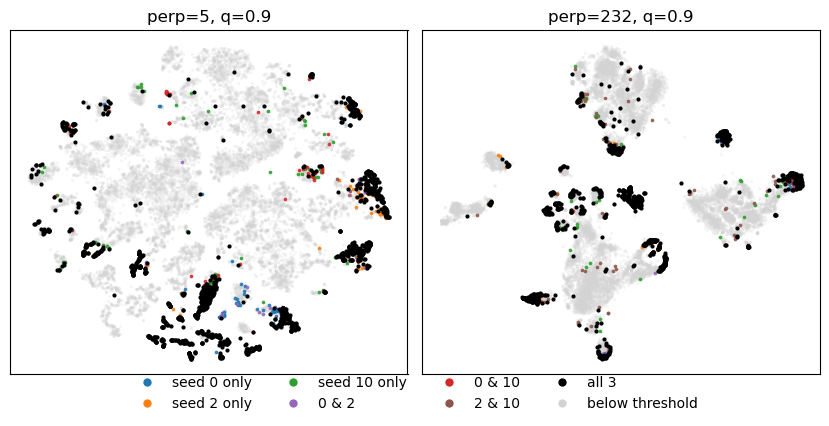

In [70]:
quantiles = np.linspace(0.875, 0.975, 20)
plot_seed_overlap_grid(
    dataset_name="hydra", teacher='',
    per_sample_recon_medal_all_tsne=per_sample_recon_medal_all_tsne,
    perps=(5, 232),
    quantiles=(0.9,),
    ref_seed=0,
    seed_labels=(0, 2, 10),
)

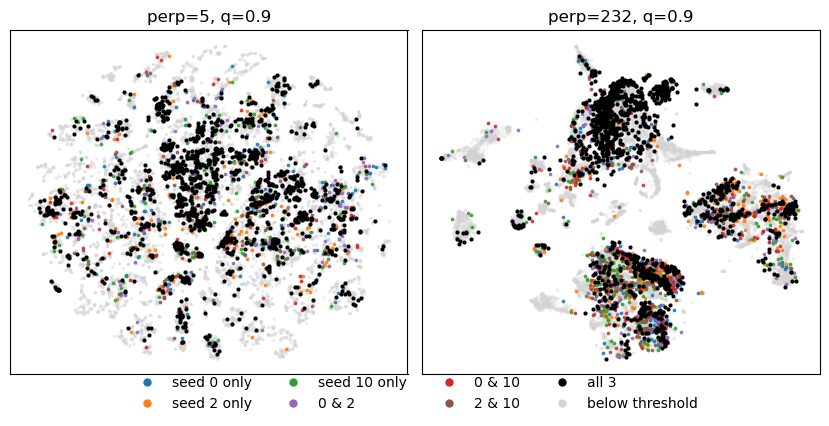

In [79]:
quantiles = np.linspace(0.875, 0.975, 20)
plot_seed_overlap_grid(
    dataset_name="hydra",teacher='pcs',
    per_sample_recon_medal_all_tsne=per_sample_recon_pcs_all_tsne,
    perps=(5, 232),
    quantiles=(0.9,),
    ref_seed=0,
    seed_labels=(0, 2, 10),
)

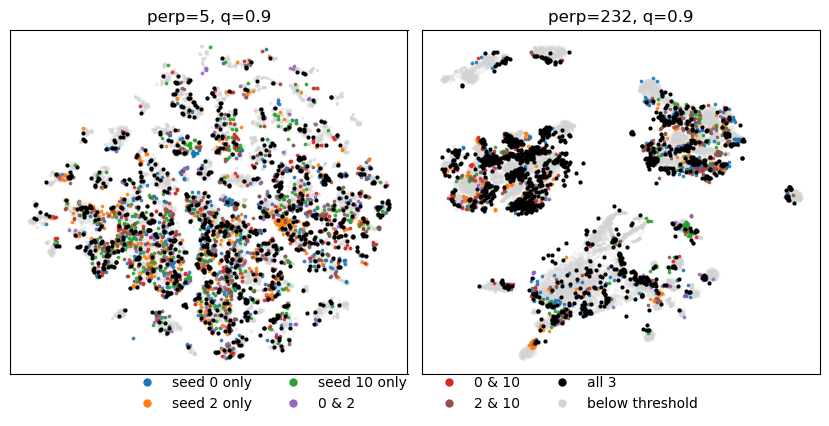

In [83]:
quantiles = np.linspace(0.875, 0.975, 20)
plot_seed_overlap_grid(
    dataset_name="hydra",teacher='embedr',
    per_sample_recon_medal_all_tsne=per_sample_recon_embedr_all_tsne,
    perps=(5, 232),
    quantiles=(0.9,),
    ref_seed=0,
    seed_labels=(0, 2, 10),
)

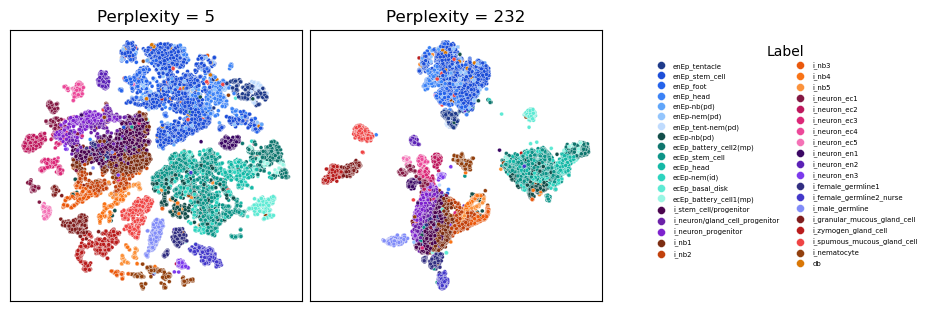

In [87]:
fig, axes = plt.subplots(1,2, figsize=(6, 3), constrained_layout=True)
axes_flat = axes.flatten()
teacher_embed = {}
teacher_embed['embedr_1'] = np.load(Path(PATH_PREFIX) / f"drd_data/embeddings2/hydra_tsne_5_0_train.npy")
teacher_embed['embedr_2'] = np.load(Path(PATH_PREFIX) / f"drd_data/embeddings2/hydra_tsne_232_0_train.npy")
sns.scatterplot(x=teacher_embed['embedr_1'][:, 0], y=teacher_embed['embedr_1'][:, 1], 
                ax=axes_flat[0], s=8, hue=y, palette = hydra_palette,
                legend=False, rasterized=True)
axes_flat[0].set_title("Perplexity = 5")
sns.scatterplot(x=teacher_embed['embedr_2'][:, 0], y=teacher_embed['embedr_2'][:, 1], 
                ax=axes_flat[1], s=8, hue=y, palette = hydra_palette,
                legend=True, rasterized=True)
axes_flat[1].set_title("Perplexity = 232")
handles, labels = axes_flat[1].get_legend_handles_labels()
axes_flat[1].legend_.remove()

label_to_handle = dict(zip(labels, handles))
ordered_keys = list(hydra_palette.keys()) 

fig.legend([label_to_handle[k] for k in ordered_keys], ordered_keys, loc='center', bbox_to_anchor=(1.3, 0.5), 
           frameon=False, title='Label', ncol=2, fontsize=5, markerscale=2, title_fontsize=10)
for ax in axes_flat:
    ax.set_xticks([])
    ax.set_yticks([])

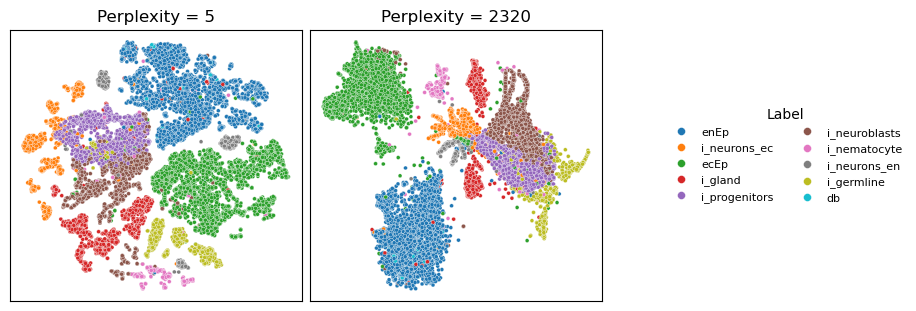

In [54]:
fig, axes = plt.subplots(1,2, figsize=(6, 3), constrained_layout=True)
axes_flat = axes.flatten()
teacher_embed = {}
teacher_embed['embedr_1'] = np.load(Path(PATH_PREFIX) / f"drd_data/embeddings2/hydra_tsne_5_0_train.npy")
teacher_embed['embedr_2'] = np.load(Path(PATH_PREFIX) / f"drd_data/embeddings2/hydra_tsne_2320_0_train.npy")
sns.scatterplot(x=teacher_embed['embedr_1'][:, 0], y=teacher_embed['embedr_1'][:, 1], 
                ax=axes_flat[0], s=8, hue=y_big_categories,
                legend=False, rasterized=True)
axes_flat[0].set_title("Perplexity = 5")
sns.scatterplot(x=teacher_embed['embedr_2'][:, 0], y=teacher_embed['embedr_2'][:, 1], 
                ax=axes_flat[1], s=8, hue=y_big_categories, 
                legend=True, rasterized=True)
axes_flat[1].set_title("Perplexity = 2320")
handles, labels = axes_flat[1].get_legend_handles_labels()
axes_flat[1].legend_.remove()

fig.legend(handles, labels, loc='center', bbox_to_anchor=(1.3, 0.5), 
           frameon=False, title='Label', ncol=2, fontsize=8, markerscale=2, title_fontsize=10)
for ax in axes_flat:
    ax.set_xticks([])
    ax.set_yticks([])

In [57]:
seeds = [0, 2, 10]

ls_97_5, ls_97_5_test = [], []

# class totals for proportion denominator
label_totals      = pd.Series(y).value_counts()
label_totals_test = pd.Series(y_test).value_counts()

for seed in seeds:
    # --- train ---
    tsne_recon_labels01 = pd.DataFrame(np.array([per_sample_recon_medal_all_tsne[5][seed], y]).T, columns=['recon_loss', 'labels'])
    tail_counts01 = tsne_recon_labels01.loc[np.where(tsne_recon_labels01['recon_loss'] >= tsne_recon_labels01['recon_loss'].quantile(0.9)), 'labels'].value_counts()
    tsne_recon_labels_97_5_percentile01 = (tail_counts01 / label_totals).dropna()

    tsne_recon_labels02 = pd.DataFrame(np.array([per_sample_recon_medal_all_tsne[2320][seed], y]).T, columns=['recon_loss', 'labels'])
    tail_counts02 = tsne_recon_labels02.loc[np.where(tsne_recon_labels02['recon_loss'] >= tsne_recon_labels02['recon_loss'].quantile(0.9)), 'labels'].value_counts()
    tsne_recon_labels_97_5_percentile02 = (tail_counts02 / label_totals).dropna()

    # --- test ---
    per_sample_recon_test = []
    for perp in [5, 2320]:
        teacher_embed = np.load(Path(PATH_PREFIX) / f"drd_data/embeddings2/hydra_tsne_{perp}_{seed}_train.npy")
        student = load_trained_ae(Path(PATH_PREFIX) / f"drd_data/tmp_results/chkpt_teacher_seed/hydra/medal_tsne2_{perp}_tc0_{seed}_ckpts/final.pt",
                input_dim=500, hidden_dims=[256, 1024, 1024, 1024],
                latent_dim=2, batchnorm=True)
        student_recon, student_embed = student(torch.tensor(X, dtype=torch.float32))
        train_distill = np.mean((teacher_embed - student_embed.detach().numpy()) ** 2)
        if train_distill < 1e-5:
            x_test_recon, _ = student(torch.tensor(X_test, dtype=torch.float32))
            test_recon = np.mean((x_test_recon.detach().numpy() - X_test)**2, axis=1)
            per_sample_recon_test.append(test_recon)
        else:
            print(f"Skipping param {perp} seed {seed} due to distillation loss {train_distill}")

    tsne_recon_labels01_test = pd.DataFrame(np.array([per_sample_recon_test[0], y_test]).T, columns=['recon_loss', 'labels'])
    tail_counts01_test = tsne_recon_labels01_test.loc[np.where(tsne_recon_labels01_test['recon_loss'] >= tsne_recon_labels01_test['recon_loss'].quantile(0.9)), 'labels'].value_counts()
    tsne_recon_labels_97_5_percentile01_test = (tail_counts01_test / label_totals_test).dropna()

    tsne_recon_labels02_test = pd.DataFrame(np.array([per_sample_recon_test[1], y_test]).T, columns=['recon_loss', 'labels'])
    tail_counts02_test = tsne_recon_labels02_test.loc[np.where(tsne_recon_labels02_test['recon_loss'] >= tsne_recon_labels02_test['recon_loss'].quantile(0.9)), 'labels'].value_counts()
    tsne_recon_labels_97_5_percentile02_test = (tail_counts02_test / label_totals_test).dropna()

    # --- accumulate ---
    for series, ls_ in [(tsne_recon_labels_97_5_percentile01_test, ls_97_5_test),
                        (tsne_recon_labels_97_5_percentile01,      ls_97_5)]:
        for rank, (label, proportion) in enumerate(series.sort_values(ascending=False).items(), 1):
            if rank < 10:
                ls_.append({'Method': 'TSNE', 'Rank': rank, 'Label': label, 'Proportion': proportion, 'Seed': seed})



/tmp/ipykernel_21037/1041672765.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sd = torch.load(ckpt_path, map_location="cpu")


loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0


/tmp/ipykernel_21037/1041672765.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sd = torch.load(ckpt_path, map_location="cpu")


loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0


/tmp/ipykernel_21037/1041672765.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sd = torch.load(ckpt_path, map_location="cpu")


loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0


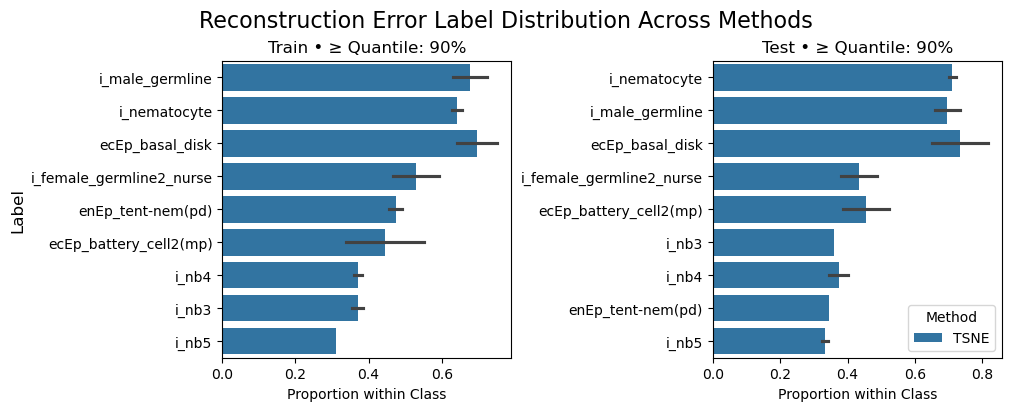

In [58]:
# --- plotting ---
df_97_5      = pd.DataFrame(ls_97_5)
df_97_5_test = pd.DataFrame(ls_97_5_test)

fig, ax = plt.subplots(1, 2, figsize=(10, 4), sharey=False, sharex=False, constrained_layout=True)
axes_flat = ax.flatten()

sns.barplot(data=df_97_5,      x='Proportion', y='Label', hue='Method', ax=axes_flat[0], legend=False, orient='y', errorbar='sd')
axes_flat[0].set_title('Train • ≥ Quantile: 90%')
axes_flat[0].set_ylabel('Label', fontsize=12)
axes_flat[0].set_xlabel('Proportion within Class')

sns.barplot(data=df_97_5_test, x='Proportion', y='Label', hue='Method', ax=axes_flat[1], orient='y', errorbar='sd')
axes_flat[1].set_title('Test • ≥ Quantile: 90%')
axes_flat[1].set_ylabel('')
axes_flat[1].set_xlabel('Proportion within Class')

fig.suptitle('Reconstruction Error Label Distribution Across Methods', fontsize=16)
plt.show()

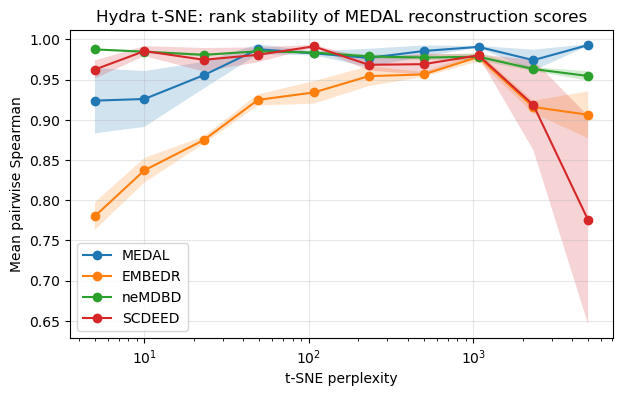

In [61]:
medal_pairwise_spearman_df, medal_mean_spearman_by_perp = summarize_rank_correlation(
    per_sample_recon_medal_all_tsne
)
embedr_pairwise_spearman_df, embedr_mean_spearman_by_perp = summarize_rank_correlation(
    per_sample_recon_embedr_all_tsne
)

pcs_pairwise_spearman_df, pcs_mean_spearman_by_perp = summarize_rank_correlation(
    per_sample_recon_pcs_all_tsne
)
scdeed_pairwise_spearman_df, scdeed_mean_spearman_by_perp = summarize_rank_correlation(
    per_sample_recon_scdeed_all_tsne
)

plt.figure(figsize=(7, 4))
plt.plot(
    medal_mean_spearman_by_perp["hyperparam"],
    medal_mean_spearman_by_perp["mean_pairwise_spearman"],
    marker="o", label = 'MEDAL'
)
plt.plot(
    embedr_mean_spearman_by_perp["hyperparam"],
    embedr_mean_spearman_by_perp["mean_pairwise_spearman"],
    marker="o", label = 'EMBEDR'
)
plt.plot(
    pcs_mean_spearman_by_perp["hyperparam"],
    pcs_mean_spearman_by_perp["mean_pairwise_spearman"],
    marker="o", label = 'neMDBD'
)
plt.plot(
    scdeed_mean_spearman_by_perp["hyperparam"],
    scdeed_mean_spearman_by_perp["mean_pairwise_spearman"],
    marker="o", label = 'SCDEED'
)

plt.fill_between(
    medal_mean_spearman_by_perp["hyperparam"],
    medal_mean_spearman_by_perp["mean_pairwise_spearman"] - medal_mean_spearman_by_perp["std_pairwise_spearman"].fillna(0),
    medal_mean_spearman_by_perp["mean_pairwise_spearman"] + medal_mean_spearman_by_perp["std_pairwise_spearman"].fillna(0),
    alpha=0.2
)
plt.fill_between(
    embedr_mean_spearman_by_perp["hyperparam"],
    embedr_mean_spearman_by_perp["mean_pairwise_spearman"] - embedr_mean_spearman_by_perp["std_pairwise_spearman"].fillna(0),
    embedr_mean_spearman_by_perp["mean_pairwise_spearman"] + embedr_mean_spearman_by_perp["std_pairwise_spearman"].fillna(0),
    alpha=0.2
)
plt.fill_between(
    pcs_mean_spearman_by_perp["hyperparam"],
    pcs_mean_spearman_by_perp["mean_pairwise_spearman"] - pcs_mean_spearman_by_perp["std_pairwise_spearman"].fillna(0),
    pcs_mean_spearman_by_perp["mean_pairwise_spearman"] + pcs_mean_spearman_by_perp["std_pairwise_spearman"].fillna(0),
    alpha=0.2
)
plt.fill_between(
    scdeed_mean_spearman_by_perp["hyperparam"],
    scdeed_mean_spearman_by_perp["mean_pairwise_spearman"] - scdeed_mean_spearman_by_perp["std_pairwise_spearman"].fillna(0),
    scdeed_mean_spearman_by_perp["mean_pairwise_spearman"] + scdeed_mean_spearman_by_perp["std_pairwise_spearman"].fillna(0),
    alpha=0.2
)
plt.xscale("log")
plt.legend()
plt.xlabel("t-SNE perplexity")
plt.ylabel("Mean pairwise Spearman")
plt.title("Hydra t-SNE: rank stability of MEDAL reconstruction scores")
plt.grid(True, alpha=0.3)
plt.show()

In [62]:
quantiles = np.linspace(0.875, 0.975, 20)
j3_medal_teachers, core_medal_teachers = zip(*[
    jaccard_curve(per_sample_recon_medal_all_tsne[perp], quantiles)
    for perp in tsne_param_sweep
])
j3_medal_teachers = np.array(j3_medal_teachers)
core_medal_teachers = np.array(core_medal_teachers)

j3_embedr_teachers, core_embedr_teachers = zip(*[
    jaccard_curve(per_sample_recon_embedr_all_tsne[perp], quantiles)
    for perp in tsne_param_sweep
])
j3_embedr_teachers = np.array(j3_embedr_teachers)
core_embedr_teachers = np.array(core_embedr_teachers)

j3_pcs_teachers, core_pcs_teachers = zip(*[
    jaccard_curve(per_sample_recon_pcs_all_tsne[perp], quantiles)
    for perp in tsne_param_sweep
])
j3_pcs_teachers = np.array(j3_pcs_teachers)
core_pcs_teachers = np.array(core_pcs_teachers)

j3_scdeed_teachers = [np.logical_and.reduce([per_sample_recon_scdeed_all_tsne[perp][s] for s in [0, 2, 10]]).sum() /
                      np.logical_or.reduce([per_sample_recon_scdeed_all_tsne[perp][s] for s in [0, 2, 10]]).sum()
                     for perp in tsne_param_sweep]

q=0.875, inter=1775, union=2274, mean_set_size=2004.0
q=0.880, inter=1700, union=2181, mean_set_size=1920.0
q=0.886, inter=1635, union=2086, mean_set_size=1836.0
q=0.891, inter=1551, union=1987, mean_set_size=1751.0
q=0.896, inter=1479, union=1888, mean_set_size=1667.0
q=0.901, inter=1412, union=1784, mean_set_size=1583.0
q=0.907, inter=1335, union=1687, mean_set_size=1498.0
q=0.912, inter=1261, union=1593, mean_set_size=1414.0
q=0.917, inter=1189, union=1491, mean_set_size=1329.0
q=0.922, inter=1108, union=1391, mean_set_size=1245.0
q=0.928, inter=1025, union=1294, mean_set_size=1161.0
q=0.933, inter=944, union=1207, mean_set_size=1076.0
q=0.938, inter=860, union=1124, mean_set_size=992.0
q=0.943, inter=794, union=1025, mean_set_size=908.0
q=0.949, inter=718, union=926, mean_set_size=823.0
q=0.954, inter=647, union=833, mean_set_size=739.0
q=0.959, inter=572, union=731, mean_set_size=654.0
q=0.964, inter=490, union=647, mean_set_size=570.0
q=0.970, inter=414, union=552, mean_set_size=

q=0.901, inter=1056, union=3067, mean_set_size=1978.3
q=0.907, inter=987, union=2937, mean_set_size=1873.3
q=0.912, inter=920, union=2802, mean_set_size=1767.0
q=0.917, inter=842, union=2663, mean_set_size=1662.0
q=0.922, inter=772, union=2520, mean_set_size=1556.0
q=0.928, inter=705, union=2382, mean_set_size=1451.7
q=0.933, inter=649, union=2229, mean_set_size=1345.0
q=0.938, inter=594, union=2067, mean_set_size=1240.0
q=0.943, inter=534, union=1909, mean_set_size=1134.0
q=0.949, inter=467, union=1749, mean_set_size=1029.0
q=0.954, inter=408, union=1602, mean_set_size=923.3
q=0.959, inter=352, union=1435, mean_set_size=818.7
q=0.964, inter=295, union=1267, mean_set_size=712.0
q=0.970, inter=243, union=1100, mean_set_size=607.0
q=0.975, inter=193, union=927, mean_set_size=502.3
q=0.875, inter=1474, union=3638, mean_set_size=2507.0
q=0.880, inter=1385, union=3524, mean_set_size=2400.7
q=0.886, inter=1321, union=3378, mean_set_size=2295.0
q=0.891, inter=1240, union=3255, mean_set_size=2

q=0.875, inter=1788, union=3274, mean_set_size=2506.0
q=0.880, inter=1694, union=3162, mean_set_size=2400.0
q=0.886, inter=1598, union=3057, mean_set_size=2295.0
q=0.891, inter=1502, union=2946, mean_set_size=2189.0
q=0.896, inter=1395, union=2838, mean_set_size=2084.0
q=0.901, inter=1302, union=2727, mean_set_size=1978.0
q=0.907, inter=1199, union=2621, mean_set_size=1873.0
q=0.912, inter=1111, union=2487, mean_set_size=1767.0
q=0.917, inter=1019, union=2379, mean_set_size=1662.0
q=0.922, inter=922, union=2277, mean_set_size=1556.0
q=0.928, inter=839, union=2154, mean_set_size=1451.0
q=0.933, inter=765, union=2028, mean_set_size=1345.0
q=0.938, inter=684, union=1898, mean_set_size=1240.0
q=0.943, inter=594, union=1769, mean_set_size=1134.0
q=0.949, inter=504, union=1652, mean_set_size=1029.0
q=0.954, inter=427, union=1525, mean_set_size=923.0
q=0.959, inter=369, union=1386, mean_set_size=818.0
q=0.964, inter=303, union=1250, mean_set_size=712.0
q=0.970, inter=240, union=1093, mean_set

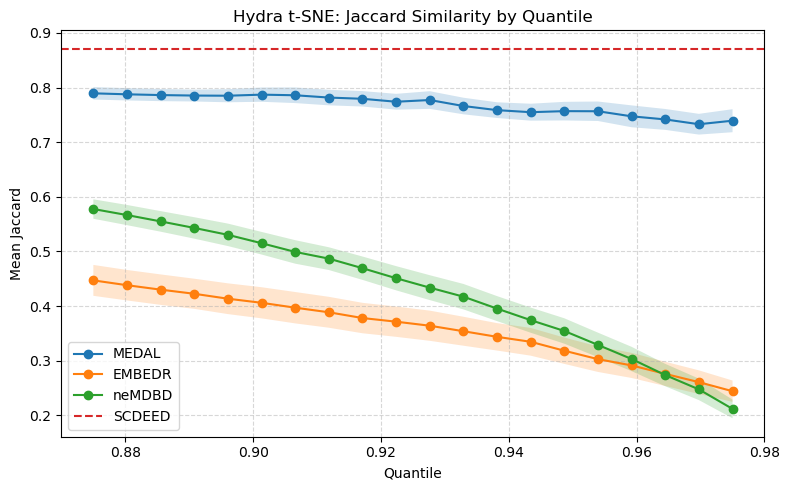

In [63]:
quantiles = np.linspace(0.875, 0.975, 20)

results = {
    "MEDAL": j3_medal_teachers,
    "EMBEDR": j3_embedr_teachers,
    "neMDBD": j3_pcs_teachers,
}

fig, ax = plt.subplots(figsize=(8, 5))

for label, data in results.items():
    means = data.mean(axis=0)      # (10,)
    se = data.std(axis=0) / np.sqrt(data.shape[0])  # (10,)

    ax.plot(quantiles, means, marker='o', label=label)
    ax.fill_between(quantiles, means - se, means + se, alpha=0.2)

ax.axhline(y = np.mean(j3_scdeed_teachers), ls = '--', label='SCDEED', color='tab:red')
ax.set_xlabel("Quantile")
ax.set_ylabel("Mean Jaccard")
ax.set_title("Hydra t-SNE: Jaccard Similarity by Quantile")
ax.legend()
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [64]:
umap_param_sweep = np.unique(np.logspace(np.log10(5), np.log10(2000), 10).astype(int))
per_sample_recon_medal_all_umap = {n: {} for n in umap_param_sweep}
per_sample_recon_scdeed_all_umap = {n: {} for n in umap_param_sweep}
per_sample_recon_embedr_all_umap = {n: {} for n in umap_param_sweep}
for s in [0, 2, 10]:
    scdeed_df = pd.read_csv(Path(PATH_PREFIX) / f"MEDAL/comparisons/results_scdeed_umap/seed{s}/umap_best_hydra_train_full_results.csv", index_col=0)
    embedr_df = pd.read_csv(Path(PATH_PREFIX) / f'MEDAL/comparisons/results_embedr_umap_seed{s}/hydra_train/scores_per_point_all_n_neighbors.csv', index_col=0)
    for n in umap_param_sweep:
        teacher_embed = np.load(Path(PATH_PREFIX) / f"drd_data/embeddings2/hydra_umap_{n}_0.1_{s}_train.npy")
        student = load_trained_ae(Path(PATH_PREFIX) / f"drd_data/tmp_results/chkpt_teacher_seed/hydra/medal_umap2_{n}_0.1_tc0_{s}_ckpts/final.pt",
                    input_dim=500,
                    hidden_dims=[309, 1792, 1792, 1792],
                    latent_dim=2, batchnorm=True)
        
        student_recon, student_embed = student(torch.tensor(X, dtype=torch.float32))
        train_distill = np.mean((teacher_embed - student_embed.detach().numpy()) ** 2)
        if train_distill < 1e-5:
            per_sample_recon = np.mean((student_recon.detach().numpy() - X)**2, axis=1)
            per_sample_recon_medal_all_umap[n][s] = per_sample_recon
        
        
        per_sample_scdeed = split_scdeed_labels(scdeed_df, n)['label']
        per_sample_recon_scdeed_all_umap[n][s] = per_sample_scdeed == "dubious"
        per_sample_embedr = embedr_df.loc[n, 'embedr_pval']
        per_sample_recon_embedr_all_umap[n][s] = per_sample_embedr
    

/tmp/ipykernel_21037/1041672765.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sd = torch.load(ckpt_path, map_location="cpu")


loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0


/tmp/ipykernel_21037/1041672765.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sd = torch.load(ckpt_path, map_location="cpu")


loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0


/tmp/ipykernel_21037/1041672765.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sd = torch.load(ckpt_path, map_location="cpu")


loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0


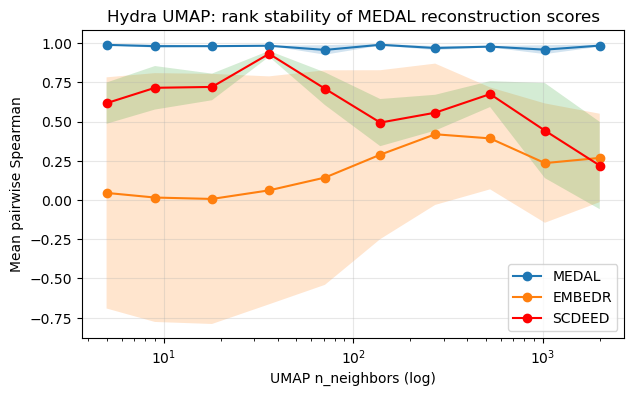

In [26]:
medal_pairwise_spearman_df, medal_mean_spearman_by_perp = summarize_rank_correlation(
    per_sample_recon_medal_all_umap
)
embedr_pairwise_spearman_df, embedr_mean_spearman_by_perp = summarize_rank_correlation(
    per_sample_recon_embedr_all_umap
)
scdeed_pairwise_spearman_df, scdeed_mean_spearman_by_perp = summarize_rank_correlation(
    per_sample_recon_scdeed_all_umap
)

plt.figure(figsize=(7, 4))
plt.plot(
    medal_mean_spearman_by_perp["hyperparam"],
    medal_mean_spearman_by_perp["mean_pairwise_spearman"],
    marker="o", label = 'MEDAL'
)
plt.plot(
    embedr_mean_spearman_by_perp["hyperparam"],
    embedr_mean_spearman_by_perp["mean_pairwise_spearman"],
    marker="o", label = 'EMBEDR'
)
plt.plot(
    scdeed_mean_spearman_by_perp["hyperparam"],
    scdeed_mean_spearman_by_perp["mean_pairwise_spearman"],
    marker="o", label = 'SCDEED', color='red'
)

plt.fill_between(
    medal_mean_spearman_by_perp["hyperparam"],
    medal_mean_spearman_by_perp["mean_pairwise_spearman"] - medal_mean_spearman_by_perp["std_pairwise_spearman"].fillna(0),
    medal_mean_spearman_by_perp["mean_pairwise_spearman"] + medal_mean_spearman_by_perp["std_pairwise_spearman"].fillna(0),
    alpha=0.2
)
plt.fill_between(
    embedr_mean_spearman_by_perp["hyperparam"],
    embedr_mean_spearman_by_perp["mean_pairwise_spearman"] - embedr_mean_spearman_by_perp["std_pairwise_spearman"].fillna(0),
    embedr_mean_spearman_by_perp["mean_pairwise_spearman"] + embedr_mean_spearman_by_perp["std_pairwise_spearman"].fillna(0),
    alpha=0.2
)
plt.fill_between(
    scdeed_mean_spearman_by_perp["hyperparam"],
    scdeed_mean_spearman_by_perp["mean_pairwise_spearman"] - scdeed_mean_spearman_by_perp["std_pairwise_spearman"].fillna(0),
    scdeed_mean_spearman_by_perp["mean_pairwise_spearman"] + scdeed_mean_spearman_by_perp["std_pairwise_spearman"].fillna(0),
    alpha=0.2
)
plt.xscale("log")
plt.legend()
plt.xlabel("UMAP n_neighbors (log)")
plt.ylabel("Mean pairwise Spearman")
plt.title("Hydra UMAP: rank stability of MEDAL reconstruction scores")
plt.grid(True, alpha=0.3)
plt.show()

q=0.800, inter=2983, union=3436, mean_set_size=3207.0
q=0.810, inter=2831, union=3249, mean_set_size=3046.0
q=0.820, inter=2666, union=3105, mean_set_size=2886.0
q=0.830, inter=2521, union=2942, mean_set_size=2726.0
q=0.840, inter=2370, union=2761, mean_set_size=2565.0
q=0.850, inter=2239, union=2572, mean_set_size=2405.0
q=0.860, inter=2080, union=2404, mean_set_size=2245.0
q=0.870, inter=1930, union=2240, mean_set_size=2085.0
q=0.880, inter=1779, union=2070, mean_set_size=1924.0
q=0.890, inter=1638, union=1882, mean_set_size=1764.0
q=0.900, inter=1487, union=1721, mean_set_size=1604.0
q=0.910, inter=1327, union=1550, mean_set_size=1443.0
q=0.920, inter=1174, union=1388, mean_set_size=1283.0
q=0.930, inter=1022, union=1223, mean_set_size=1123.0
q=0.940, inter=871, union=1044, mean_set_size=962.0
q=0.950, inter=718, union=880, mean_set_size=802.0
q=0.960, inter=574, union=707, mean_set_size=642.0
q=0.970, inter=426, union=537, mean_set_size=481.0
q=0.980, inter=284, union=358, mean_set

q=0.840, inter=177, union=6548, mean_set_size=3207.7
q=0.850, inter=164, union=6177, mean_set_size=3013.3
q=0.860, inter=147, union=5808, mean_set_size=2807.0
q=0.870, inter=133, union=5448, mean_set_size=2608.3
q=0.880, inter=118, union=5060, mean_set_size=2409.0
q=0.890, inter=109, union=4715, mean_set_size=2208.0
q=0.900, inter=100, union=4323, mean_set_size=2009.3
q=0.910, inter=93, union=4005, mean_set_size=1836.7
q=0.920, inter=88, union=3609, mean_set_size=1619.7
q=0.930, inter=79, union=3213, mean_set_size=1419.7
q=0.940, inter=76, union=2787, mean_set_size=1207.7
q=0.950, inter=69, union=2362, mean_set_size=1011.0
q=0.960, inter=67, union=1885, mean_set_size=806.3
q=0.970, inter=53, union=1438, mean_set_size=603.7
q=0.980, inter=26, union=992, mean_set_size=401.3
q=0.990, inter=6, union=541, mean_set_size=201.3
q=0.800, inter=264, union=8338, mean_set_size=4011.0
q=0.810, inter=250, union=7981, mean_set_size=3814.7
q=0.820, inter=237, union=7610, mean_set_size=3618.0
q=0.830, 

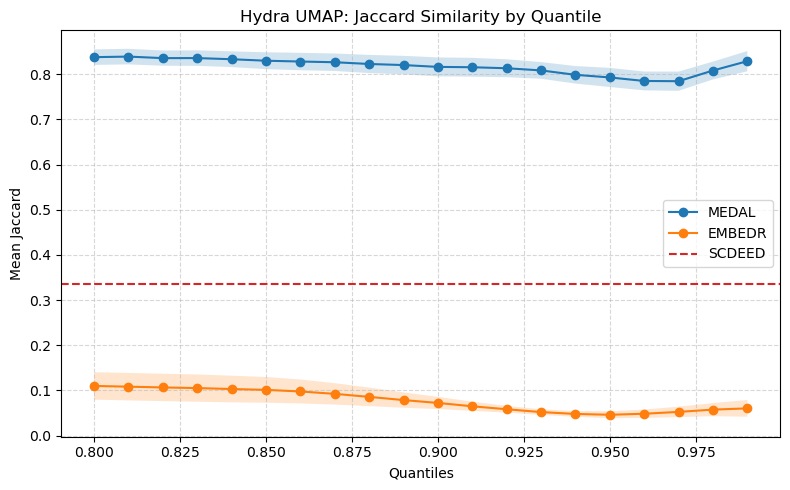

In [27]:
j3_medal_teachers, core_medal_teachers = zip(*[
    jaccard_curve(per_sample_recon_medal_all_umap[n], np.linspace(0.8, 0.99, 20))
    for n in umap_param_sweep
])
j3_medal_teachers = np.array(j3_medal_teachers)
core_medal_teachers = np.array(core_medal_teachers)

j3_embedr_teachers, core_embedr_teachers = zip(*[
    jaccard_curve(per_sample_recon_embedr_all_umap[n], np.linspace(0.8, 0.99, 20))
    for n in umap_param_sweep
])
j3_embedr_teachers = np.array(j3_embedr_teachers)
core_embedr_teachers = np.array(core_embedr_teachers)

j3_scdeed_teachers = [np.logical_and.reduce([per_sample_recon_scdeed_all_umap[n][s] for s in [0, 2, 10]]).sum() /
                      np.logical_or.reduce([per_sample_recon_scdeed_all_umap[n][s] for s in [0, 2, 10]]).sum()
                     for n in umap_param_sweep]

quantiles = np.linspace(0.8, 0.99, 20)

results = {
    "MEDAL": j3_medal_teachers,
    "EMBEDR": j3_embedr_teachers,
}

fig, ax = plt.subplots(figsize=(8, 5))

for label, data in results.items():          
    means = data.mean(axis=0)      
    se = data.std(axis=0) / np.sqrt(data.shape[0])  

    ax.plot(quantiles,means, marker='o', label=label)
    ax.fill_between(quantiles, means - se, means + se, alpha=0.2)

ax.axhline(y = np.mean(j3_scdeed_teachers), ls = '--', label='SCDEED', color='tab:red')
ax.set_xlabel("Quantiles")
ax.set_ylabel("Mean Jaccard")
ax.set_title("Hydra UMAP: Jaccard Similarity by Quantile")
ax.legend()
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [105]:
hydra_compare_t_res_dict = []
for s in range(5):
    for n in np.unique(np.logspace(np.log10(5), np.log10(500), 15).astype(int)):
        for teacher in ["tsne", "spectral", "phate", "umap"]:
            if teacher == "umap":
                teacher_embed = np.load(Path(PATH_PREFIX) / f"drd_data/embeddings2/hydra_{teacher}_{n}_0.1_0_train.npy")
            elif teacher == "phate":
                teacher_embed = np.load(Path(PATH_PREFIX) / f"drd_data/embeddings2/hydra_{teacher}2_{n}_0_train.npy")
            else:
                teacher_embed = np.load(Path(PATH_PREFIX) / f"drd_data/embeddings2/hydra_{teacher}_{n}_0_train.npy")
            
            if teacher == "umap":
                student = load_trained_ae(Path(PATH_PREFIX) / f"drd_data/tmp_results/chkpt_teacher_comparison/hydra/medal_{teacher}2_{n}_0.1_tc0_{s}_ckpts/final.pt",
                    input_dim=500,
                    hidden_dims=[256, 1024, 1024,1024],
                    latent_dim=2, batchnorm=True)
            else:
                student = load_trained_ae(Path(PATH_PREFIX) / f"drd_data/tmp_results/chkpt_teacher_comparison/hydra/medal_{teacher}2_{n}_tc0_{s}_ckpts/final.pt",
                    input_dim=500,
                    hidden_dims=[256, 1024, 1024,1024],
                    latent_dim=2, batchnorm=True)

            student_recon, student_embed = student(torch.tensor(X, dtype=torch.float32))
            train_distill = np.mean((teacher_embed - student_embed.detach().numpy()) ** 2)
            if train_distill < 1e-5:
                train_recon = np.mean((student_recon.detach().numpy() - X)**2)
                hydra_compare_t_res_dict.append({"n_neighbors": n, "recon_loss": train_recon, "split": "Train", "seed": s, "teacher": teacher})

                x_val_recon, _ = student(torch.tensor(X_val, dtype=torch.float32))
                val_recon = np.mean((x_val_recon.detach().numpy() - X_val)**2)
                hydra_compare_t_res_dict.append({"n_neighbors": n, "recon_loss": val_recon, "split": "Val", "seed": s, "teacher": teacher})

                x_test_recon, _ = student(torch.tensor(X_test, dtype=torch.float32))
                test_recon = np.mean((x_test_recon.detach().numpy() - X_test)**2)
                hydra_compare_t_res_dict.append({"n_neighbors": n, "recon_loss": test_recon, "split": "Test", "seed": s, "teacher": teacher})
            else:
                print(f"Skipping param {n} seed {s} due to distillation loss {train_distill}")

/tmp/ipykernel_21037/1041672765.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sd = torch.load(ckpt_path, map_location="cpu")


loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded par

loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded par

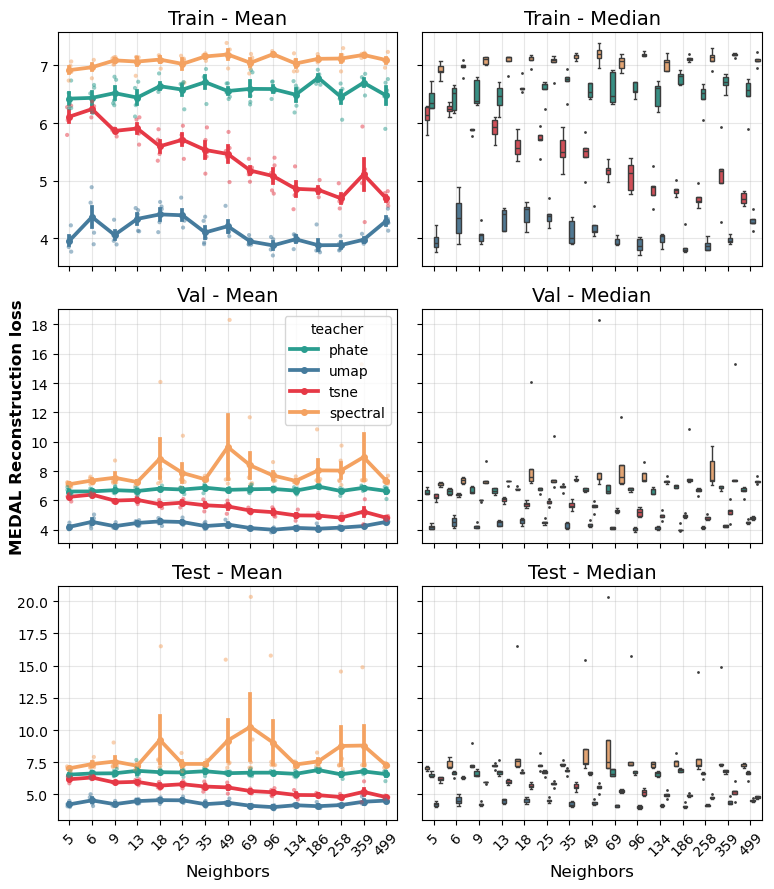

In [110]:
analysis = pd.DataFrame(hydra_compare_t_res_dict)
analysis.sort_values(by='n_neighbors', inplace=True)
palette = {
    "tsne":     "#E63946",
    "umap":     "#457B9D",
    "phate":    "#2A9D8F",
    "spectral": "#F4A261",
}
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(8, 9), sharey='row', sharex=True)
for i, split in enumerate(['Train', 'Val', 'Test']):
    subset = analysis[analysis.split == split]
    
    # Left Column: Pointplot + Stripplot
    ax_point = axes[i, 0]
    sns.pointplot(data=subset, x="n_neighbors", y="recon_loss", errorbar="se", 
                  hue="teacher", ax=ax_point, markersize=3, palette=palette, legend=True if i == 1 else False)
    sns.stripplot(data=subset, x="n_neighbors", y="recon_loss", 
                  hue="teacher", size=3, alpha=0.5, ax=ax_point, palette=palette, legend=False)
    
    ax_point.set_title(f"{split} - Mean", fontsize=14)
    
    # Right Column: Boxplot
    ax_box = axes[i, 1]
    sns.boxplot(data=subset, x="n_neighbors", y="recon_loss", ax=ax_box, 
                hue='teacher', palette=palette, legend=False, fliersize=1)
    ax_box.set_title(f"{split} - Median", fontsize=14)
    
    for ax in [ax_point, ax_box]:
        ax.grid(True, alpha=0.3)
        ax.set_xlabel("Neighbors", fontsize=12)
        ax.set_ylabel("")
        plt.setp(ax.get_xticklabels(), rotation=45, ha='center')
        
#     if split == "Val":
#         ax_point.axvline(x=test_stats.index.get_loc(tsne_one_std_param_choice), ls='--', c='black')
#         ax_box.axvline(x=pos_median, ls='--', c='black')

# axes[1,0].fill_between(
#     x_coords, 
#     tsne_one_std_range[0], 
#     tsne_one_std_range[1], 
#     color="red", 
#     alpha=0.2, 
#     label='1 SEM'
# )
# axes[1,0].set_xlim(-0.5,7.5)
axes[1,0].set_ylabel("MEDAL Reconstruction loss", fontsize=12, fontweight='bold')
# for i in range(3):
#     axes[i,0].yaxis.set_major_formatter(ticker.ScalarFormatter())
#     axes[i,0].ticklabel_format(style='sci', axis='y', scilimits=(-2,-2))
#     axes[i,0].yaxis.get_offset_text().set_fontsize(8)

plt.tight_layout()
plt.show()

## Tasic

In [88]:
X_og, X_test, y_og, y_test = load_and_split("tasic", test_size=0.2, seed=0, labels=True)
X, X_val, y, y_val = train_test_split(X_og, y_og, test_size=0.2, random_state=0)
labels = np.load(Path(PATH_PREFIX) / 'drd_data/tasic_cluster_labels.npy', allow_pickle=True)
colors = np.load(Path(PATH_PREFIX) / 'drd_data/tasic_cluster_colors.npy', allow_pickle=True)
categories = np.unique(labels)
tasic_palette = {cat: col for cat, col in zip(categories, colors)}

class_labels = np.load(Path(PATH_PREFIX) / 'drd_data/tasic_class_labels.npy', allow_pickle=True)
y_class_og, y_class_test = train_test_split(class_labels, test_size=0.2, random_state=0)
y_class, y_class_val = train_test_split(y_class_og, test_size=0.2, random_state=0)
class_colors = np.load(Path(PATH_PREFIX) / 'drd_data/tasic_class_colors.npy', allow_pickle=True)
tasic_palette_class = {"Glutamatergic": "#e5b68b", "GABAergic": "#307c47", "Non-Neuronal": "#2C94EF", "Endothelial": "#32D7FC"}

In [89]:
tsne_param_sweep = np.unique(np.logspace(np.log10(5), np.log10(6000), 10).astype(int))
per_sample_recon_medal_all_tsne = {perp: {} for perp in tsne_param_sweep}
per_sample_recon_scdeed_all_tsne = {perp: {} for perp in tsne_param_sweep}
per_sample_recon_embedr_all_tsne = {perp: {} for perp in tsne_param_sweep}
per_sample_recon_pcs_all_tsne = {perp: {} for perp in tsne_param_sweep}
for s in [0, 2, 10]:
    pcs_df = pd.read_csv(Path(PATH_PREFIX) / f'MEDAL/comparisons/results_pcs_seed{s}/tasic_train/scores_per_point_all_perplexities.csv', index_col=0)
    scdeed_df = pd.read_csv(Path(PATH_PREFIX) / f"MEDAL/comparisons/results_scdeed_tsne/seed{s}/tsne_best_tasic_train_full_results.csv", index_col=0)
    embedr_df = pd.read_csv(Path(PATH_PREFIX) / f'MEDAL/comparisons/results_embedr_tsne_seed{s}/tasic_train/scores_per_point_all_perplexities.csv', index_col=0)
    for perp in tsne_param_sweep:
        teacher_embed = np.load(Path(PATH_PREFIX) / f"drd_data/embeddings2/tasic_tsne_{perp}_{s}_train.npy")
        student = load_trained_ae(Path(PATH_PREFIX) / f"drd_data/tmp_results/chkpt_teacher_seed/tasic/medal_tsne2_{perp}_tc0_{s}_ckpts/final.pt",
                    input_dim=1000,
                    hidden_dims=[309, 1792, 1792, 1792],
                    latent_dim=2, batchnorm=True)
        
        student_recon, student_embed = student(torch.tensor(X, dtype=torch.float32))
        train_distill = np.mean((teacher_embed - student_embed.detach().numpy()) ** 2)
        if train_distill < 1e-5:
            per_sample_recon = np.mean((student_recon.detach().numpy() - X)**2, axis=1)
            per_sample_recon_medal_all_tsne[perp][s] = per_sample_recon
        
        per_sample_scdeed = split_scdeed_labels(scdeed_df, perp)['label']
        per_sample_recon_scdeed_all_tsne[perp][s] = per_sample_scdeed == "dubious"
        per_sample_embedr = embedr_df.loc[perp, 'embedr_pval']
        per_sample_recon_embedr_all_tsne[perp][s] = per_sample_embedr
        per_sample_pcs = pcs_df.loc[perp, 'sscore']
        per_sample_recon_pcs_all_tsne[perp][s] = per_sample_pcs
    

/tmp/ipykernel_21037/1041672765.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sd = torch.load(ckpt_path, map_location="cpu")


loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0


/tmp/ipykernel_21037/1041672765.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sd = torch.load(ckpt_path, map_location="cpu")


loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0


/tmp/ipykernel_21037/1041672765.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sd = torch.load(ckpt_path, map_location="cpu")


loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0


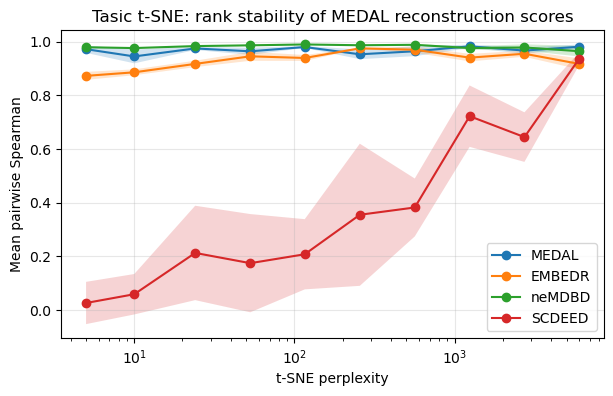

In [30]:
medal_pairwise_spearman_df, medal_mean_spearman_by_perp = summarize_rank_correlation(
    per_sample_recon_medal_all_tsne
)
embedr_pairwise_spearman_df, embedr_mean_spearman_by_perp = summarize_rank_correlation(
    per_sample_recon_embedr_all_tsne
)
pcs_pairwise_spearman_df, pcs_mean_spearman_by_perp = summarize_rank_correlation(
    per_sample_recon_pcs_all_tsne
)
scdeed_pairwise_spearman_df, scdeed_mean_spearman_by_perp = summarize_rank_correlation(
    per_sample_recon_scdeed_all_tsne
)

plt.figure(figsize=(7, 4))
plt.plot(
    medal_mean_spearman_by_perp["hyperparam"],
    medal_mean_spearman_by_perp["mean_pairwise_spearman"],
    marker="o", label = 'MEDAL'
)
plt.plot(
    embedr_mean_spearman_by_perp["hyperparam"],
    embedr_mean_spearman_by_perp["mean_pairwise_spearman"],
    marker="o", label = 'EMBEDR'
)
plt.plot(
    pcs_mean_spearman_by_perp["hyperparam"],
    pcs_mean_spearman_by_perp["mean_pairwise_spearman"],
    marker="o", label = 'neMDBD'
)
plt.plot(
    scdeed_mean_spearman_by_perp["hyperparam"],
    scdeed_mean_spearman_by_perp["mean_pairwise_spearman"],
    marker="o", label = 'SCDEED'
)

plt.fill_between(
    medal_mean_spearman_by_perp["hyperparam"],
    medal_mean_spearman_by_perp["mean_pairwise_spearman"] - medal_mean_spearman_by_perp["std_pairwise_spearman"].fillna(0),
    medal_mean_spearman_by_perp["mean_pairwise_spearman"] + medal_mean_spearman_by_perp["std_pairwise_spearman"].fillna(0),
    alpha=0.2
)
plt.fill_between(
    embedr_mean_spearman_by_perp["hyperparam"],
    embedr_mean_spearman_by_perp["mean_pairwise_spearman"] - embedr_mean_spearman_by_perp["std_pairwise_spearman"].fillna(0),
    embedr_mean_spearman_by_perp["mean_pairwise_spearman"] + embedr_mean_spearman_by_perp["std_pairwise_spearman"].fillna(0),
    alpha=0.2
)
plt.fill_between(
    pcs_mean_spearman_by_perp["hyperparam"],
    pcs_mean_spearman_by_perp["mean_pairwise_spearman"] - pcs_mean_spearman_by_perp["std_pairwise_spearman"].fillna(0),
    pcs_mean_spearman_by_perp["mean_pairwise_spearman"] + pcs_mean_spearman_by_perp["std_pairwise_spearman"].fillna(0),
    alpha=0.2
)
plt.fill_between(
    scdeed_mean_spearman_by_perp["hyperparam"],
    scdeed_mean_spearman_by_perp["mean_pairwise_spearman"] - scdeed_mean_spearman_by_perp["std_pairwise_spearman"].fillna(0),
    scdeed_mean_spearman_by_perp["mean_pairwise_spearman"] + scdeed_mean_spearman_by_perp["std_pairwise_spearman"].fillna(0),
    alpha=0.2
)
plt.xscale("log")
plt.legend()
plt.xlabel("t-SNE perplexity")
plt.ylabel("Mean pairwise Spearman")
plt.title("Tasic t-SNE: rank stability of MEDAL reconstruction scores")
plt.grid(True, alpha=0.3)
plt.show()

In [31]:
j3_medal_teachers, core_medal_teachers = zip(*[
    jaccard_curve(per_sample_recon_medal_all_tsne[perp], np.linspace(0.925, 0.99, 20))
    for perp in tsne_param_sweep
])
j3_medal_teachers = np.array(j3_medal_teachers)
core_medal_teachers = np.array(core_medal_teachers)

j3_embedr_teachers, core_embedr_teachers = zip(*[
    jaccard_curve(per_sample_recon_embedr_all_tsne[perp], np.linspace(0.925, 0.99, 20))
    for perp in tsne_param_sweep
])
j3_embedr_teachers = np.array(j3_embedr_teachers)
core_embedr_teachers = np.array(core_embedr_teachers)

j3_pcs_teachers, core_pcs_teachers = zip(*[
    jaccard_curve(per_sample_recon_pcs_all_tsne[perp], np.linspace(0.925, 0.99, 20))
    for perp in tsne_param_sweep
])
j3_pcs_teachers = np.array(j3_pcs_teachers)
core_pcs_teachers = np.array(core_pcs_teachers)

j3_scdeed_teachers = [np.logical_and.reduce([per_sample_recon_scdeed_all_tsne[perp][s] for s in [0, 2, 10]]).sum() /
                      np.logical_or.reduce([per_sample_recon_scdeed_all_tsne[perp][s] for s in [0, 2, 10]]).sum()
                     for perp in tsne_param_sweep]

q=0.925, inter=1120, union=1174, mean_set_size=1144.0
q=0.928, inter=1074, union=1109, mean_set_size=1092.0
q=0.932, inter=1026, union=1055, mean_set_size=1039.0
q=0.935, inter=976, union=996, mean_set_size=987.0
q=0.939, inter=930, union=940, mean_set_size=935.0
q=0.942, inter=879, union=887, mean_set_size=883.0
q=0.946, inter=807, union=849, mean_set_size=831.0
q=0.949, inter=722, union=824, mean_set_size=779.0
q=0.952, inter=652, union=791, mean_set_size=727.0
q=0.956, inter=576, union=761, mean_set_size=674.0
q=0.959, inter=519, union=721, mean_set_size=622.0
q=0.963, inter=457, union=676, mean_set_size=570.0
q=0.966, inter=419, union=622, mean_set_size=518.0
q=0.969, inter=384, union=549, mean_set_size=466.0
q=0.973, inter=359, union=483, mean_set_size=414.0
q=0.976, inter=327, union=403, mean_set_size=362.0
q=0.980, inter=262, union=348, mean_set_size=309.0
q=0.983, inter=209, union=303, mean_set_size=257.0
q=0.987, inter=137, union=267, mean_set_size=205.0
q=0.990, inter=84, uni

q=0.969, inter=422, union=504, mean_set_size=466.0
q=0.973, inter=354, union=470, mean_set_size=414.0
q=0.976, inter=307, union=423, mean_set_size=362.0
q=0.980, inter=248, union=379, mean_set_size=309.0
q=0.983, inter=199, union=319, mean_set_size=257.0
q=0.987, inter=154, union=264, mean_set_size=205.0
q=0.990, inter=118, union=197, mean_set_size=153.0
q=0.925, inter=789, union=2163, mean_set_size=1430.0
q=0.928, inter=754, union=2076, mean_set_size=1365.3
q=0.932, inter=714, union=1989, mean_set_size=1299.3
q=0.935, inter=677, union=1890, mean_set_size=1234.0
q=0.939, inter=634, union=1805, mean_set_size=1169.0
q=0.942, inter=589, union=1711, mean_set_size=1104.3
q=0.946, inter=549, union=1623, mean_set_size=1039.7
q=0.949, inter=523, union=1525, mean_set_size=973.3
q=0.952, inter=476, union=1437, mean_set_size=908.3
q=0.956, inter=438, union=1339, mean_set_size=843.3
q=0.959, inter=394, union=1255, mean_set_size=778.3
q=0.963, inter=357, union=1157, mean_set_size=713.7
q=0.966, int

q=0.956, inter=431, union=1316, mean_set_size=843.0
q=0.959, inter=395, union=1230, mean_set_size=778.0
q=0.963, inter=348, union=1141, mean_set_size=713.0
q=0.966, inter=311, union=1043, mean_set_size=647.0
q=0.969, inter=265, union=961, mean_set_size=582.0
q=0.973, inter=232, union=866, mean_set_size=517.0
q=0.976, inter=191, union=769, mean_set_size=452.0
q=0.980, inter=155, union=670, mean_set_size=387.0
q=0.983, inter=121, union=571, mean_set_size=321.0
q=0.987, inter=79, union=493, mean_set_size=256.0
q=0.990, inter=49, union=387, mean_set_size=191.0
q=0.925, inter=992, union=1896, mean_set_size=1430.0
q=0.928, inter=931, union=1824, mean_set_size=1365.0
q=0.932, inter=879, union=1761, mean_set_size=1299.0
q=0.935, inter=824, union=1691, mean_set_size=1234.0
q=0.939, inter=768, union=1607, mean_set_size=1169.0
q=0.942, inter=726, union=1515, mean_set_size=1104.0
q=0.946, inter=677, union=1437, mean_set_size=1039.0
q=0.949, inter=623, union=1359, mean_set_size=973.0
q=0.952, inter

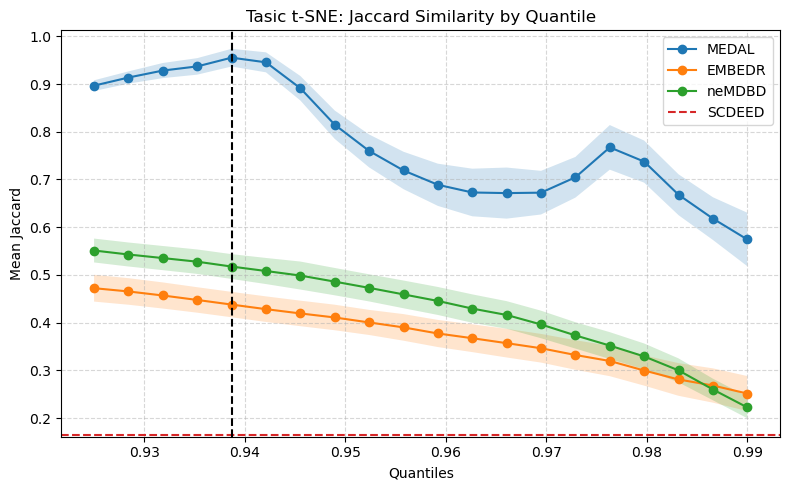

In [32]:
quantiles = np.linspace(0.925, 0.99, 20)

results = {
    "MEDAL": j3_medal_teachers,
    "EMBEDR": j3_embedr_teachers,
    "neMDBD": j3_pcs_teachers,
}

fig, ax = plt.subplots(figsize=(8, 5))

for label, data in results.items():
    print
    # arr = np.stack(data)          
    means = data.mean(axis=0)      
    se = data.std(axis=0) / np.sqrt(data.shape[0])  

    ax.plot(quantiles,means, marker='o', label=label)
    ax.fill_between(quantiles, means - se, means + se, alpha=0.2)

ax.axhline(y = np.mean(j3_scdeed_teachers), ls = '--', label='SCDEED', color='tab:red')
ax.axvline(x = quantiles[4], ls = '--', c ='black')
ax.set_xlabel("Quantiles")
ax.set_ylabel("Mean Jaccard")
ax.set_title("Tasic t-SNE: Jaccard Similarity by Quantile")
ax.legend()
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

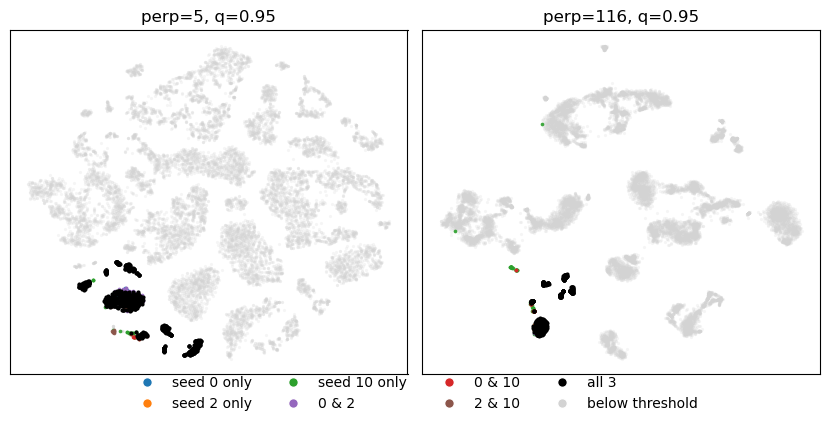

In [90]:
plot_seed_overlap_grid(
    dataset_name="tasic", teacher = '',
    per_sample_recon_medal_all_tsne=per_sample_recon_medal_all_tsne,
    perps=(5, 116),
    quantiles=(0.95,),
    ref_seed=0,
    seed_labels=(0, 2, 10),
)

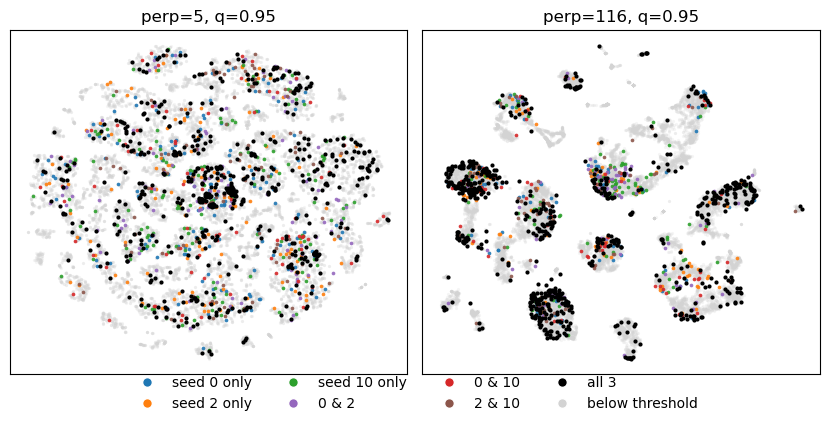

In [92]:
plot_seed_overlap_grid(
    dataset_name="tasic", teacher = 'pcs',
    per_sample_recon_medal_all_tsne=per_sample_recon_pcs_all_tsne,
    perps=(5, 116),
    quantiles=(0.95,),
    ref_seed=0,
    seed_labels=(0, 2, 10),
)

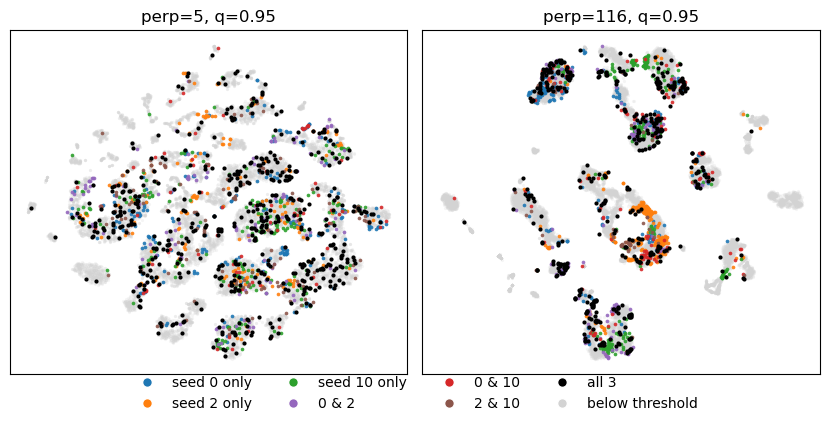

In [94]:
plot_seed_overlap_grid(
    dataset_name="tasic", teacher = 'embedr',
    per_sample_recon_medal_all_tsne=per_sample_recon_embedr_all_tsne,
    perps=(5, 116),
    quantiles=(0.95,),
    ref_seed=0,
    seed_labels=(0, 2, 10),
)

In [38]:
umap_param_sweep = np.unique(np.logspace(np.log10(5), np.log10(2000), 10).astype(int))
per_sample_recon_medal_all_umap = {n: {} for n in umap_param_sweep}
per_sample_recon_scdeed_all_umap = {n: {} for n in umap_param_sweep}
per_sample_recon_embedr_all_umap = {n: {} for n in umap_param_sweep}

for s in [0, 2, 10]:
    scdeed_df = pd.read_csv(Path(PATH_PREFIX) / f"MEDAL/comparisons/results_scdeed_umap/seed{s}/umap_best_tasic_train_full_results.csv", index_col=0)
    embedr_df = pd.read_csv(Path(PATH_PREFIX) / f'MEDAL/comparisons/results_embedr_umap_seed{s}/tasic_train/scores_per_point_all_n_neighbors.csv', index_col=0)
    for n in umap_param_sweep:
        teacher_embed = np.load(Path(PATH_PREFIX) / f"drd_data/embeddings2/tasic_umap_{n}_0.1_{s}_train.npy")
        student = load_trained_ae(Path(PATH_PREFIX) / f"drd_data/tmp_results/chkpt_teacher_seed/tasic/medal_umap2_{n}_0.1_tc0_{s}_ckpts/final.pt",
                    input_dim=1000,
                    hidden_dims=[309, 1792, 1792, 1792],
                    latent_dim=2, batchnorm=True)
        
        student_recon, student_embed = student(torch.tensor(X, dtype=torch.float32))
        train_distill = np.mean((teacher_embed - student_embed.detach().numpy()) ** 2)
        if train_distill < 1e-5:
            per_sample_recon = np.mean((student_recon.detach().numpy() - X)**2, axis=1)
            per_sample_recon_medal_all_umap[n][s] = per_sample_recon
        
        per_sample_scdeed = split_scdeed_labels(scdeed_df, n)['label']
        per_sample_recon_scdeed_all_umap[n][s] = per_sample_scdeed == "dubious"
        per_sample_embedr = embedr_df.loc[n, 'embedr_pval']
        per_sample_recon_embedr_all_umap[n][s] = per_sample_embedr


/tmp/ipykernel_21037/1041672765.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sd = torch.load(ckpt_path, map_location="cpu")


loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0


/tmp/ipykernel_21037/1041672765.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sd = torch.load(ckpt_path, map_location="cpu")


loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0


/tmp/ipykernel_21037/1041672765.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sd = torch.load(ckpt_path, map_location="cpu")


loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0


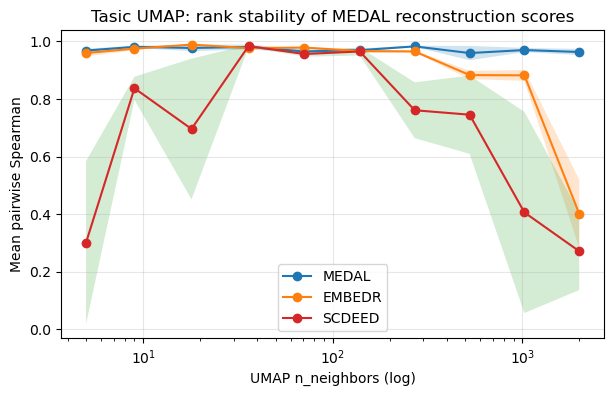

In [39]:
medal_pairwise_spearman_df, medal_mean_spearman_by_perp = summarize_rank_correlation(
    per_sample_recon_medal_all_umap
)
embedr_pairwise_spearman_df, embedr_mean_spearman_by_perp = summarize_rank_correlation(
    per_sample_recon_embedr_all_umap
)
scdeed_pairwise_spearman_df, scdeed_mean_spearman_by_perp = summarize_rank_correlation(
    per_sample_recon_scdeed_all_umap
)

plt.figure(figsize=(7, 4))
plt.plot(
    medal_mean_spearman_by_perp["hyperparam"],
    medal_mean_spearman_by_perp["mean_pairwise_spearman"],
    marker="o", label = 'MEDAL'
)
plt.plot(
    embedr_mean_spearman_by_perp["hyperparam"],
    embedr_mean_spearman_by_perp["mean_pairwise_spearman"],
    marker="o", label = 'EMBEDR'
)
plt.plot(
    scdeed_mean_spearman_by_perp["hyperparam"],
    scdeed_mean_spearman_by_perp["mean_pairwise_spearman"],
    marker="o", label = 'SCDEED', color='tab:red'
)

plt.fill_between(
    medal_mean_spearman_by_perp["hyperparam"],
    medal_mean_spearman_by_perp["mean_pairwise_spearman"] - medal_mean_spearman_by_perp["std_pairwise_spearman"].fillna(0),
    medal_mean_spearman_by_perp["mean_pairwise_spearman"] + medal_mean_spearman_by_perp["std_pairwise_spearman"].fillna(0),
    alpha=0.2
)
plt.fill_between(
    embedr_mean_spearman_by_perp["hyperparam"],
    embedr_mean_spearman_by_perp["mean_pairwise_spearman"] - embedr_mean_spearman_by_perp["std_pairwise_spearman"].fillna(0),
    embedr_mean_spearman_by_perp["mean_pairwise_spearman"] + embedr_mean_spearman_by_perp["std_pairwise_spearman"].fillna(0),
    alpha=0.2
)
plt.fill_between(
    scdeed_mean_spearman_by_perp["hyperparam"],
    scdeed_mean_spearman_by_perp["mean_pairwise_spearman"] - scdeed_mean_spearman_by_perp["std_pairwise_spearman"].fillna(0),
    scdeed_mean_spearman_by_perp["mean_pairwise_spearman"] + scdeed_mean_spearman_by_perp["std_pairwise_spearman"].fillna(0),
    alpha=0.2
)
plt.xscale("log")
plt.legend()
plt.xlabel("UMAP n_neighbors (log)")
plt.ylabel("Mean pairwise Spearman")
plt.title("Tasic UMAP: rank stability of MEDAL reconstruction scores")
plt.grid(True, alpha=0.3)
plt.show()

q=0.800, inter=2695, union=3391, mean_set_size=3049.0
q=0.810, inter=2553, union=3237, mean_set_size=2897.0
q=0.820, inter=2426, union=3081, mean_set_size=2744.0
q=0.830, inter=2311, union=2921, mean_set_size=2592.0
q=0.840, inter=2160, union=2760, mean_set_size=2440.0
q=0.850, inter=2028, union=2598, mean_set_size=2287.0
q=0.860, inter=1891, union=2422, mean_set_size=2135.0
q=0.870, inter=1760, union=2251, mean_set_size=1982.0
q=0.880, inter=1617, union=2081, mean_set_size=1830.0
q=0.890, inter=1492, union=1904, mean_set_size=1677.0
q=0.900, inter=1355, union=1730, mean_set_size=1525.0
q=0.910, inter=1213, union=1554, mean_set_size=1372.0
q=0.920, inter=1033, union=1420, mean_set_size=1220.0
q=0.930, inter=859, union=1288, mean_set_size=1068.0
q=0.940, inter=739, union=1103, mean_set_size=915.0
q=0.950, inter=640, union=892, mean_set_size=763.0
q=0.960, inter=550, union=670, mean_set_size=610.0
q=0.970, inter=391, union=510, mean_set_size=458.0
q=0.980, inter=173, union=419, mean_set_

q=0.910, inter=1224, union=1552, mean_set_size=1372.0
q=0.920, inter=1117, union=1341, mean_set_size=1220.0
q=0.930, inter=1010, union=1131, mean_set_size=1068.0
q=0.940, inter=910, union=918, mean_set_size=915.0
q=0.950, inter=751, union=775, mean_set_size=763.0
q=0.960, inter=553, union=668, mean_set_size=610.0
q=0.970, inter=412, union=513, mean_set_size=458.0
q=0.980, inter=277, union=331, mean_set_size=305.0
q=0.990, inter=123, union=184, mean_set_size=153.0
q=0.800, inter=3473, union=4224, mean_set_size=3813.7
q=0.810, inter=3295, union=4020, mean_set_size=3622.0
q=0.820, inter=3116, union=3823, mean_set_size=3432.7
q=0.830, inter=2928, union=3617, mean_set_size=3241.0
q=0.840, inter=2731, union=3432, mean_set_size=3050.3
q=0.850, inter=2555, union=3240, mean_set_size=2864.7
q=0.860, inter=2363, union=3038, mean_set_size=2670.0
q=0.870, inter=2189, union=2843, mean_set_size=2479.3
q=0.880, inter=1997, union=2642, mean_set_size=2288.3
q=0.890, inter=1804, union=2449, mean_set_size

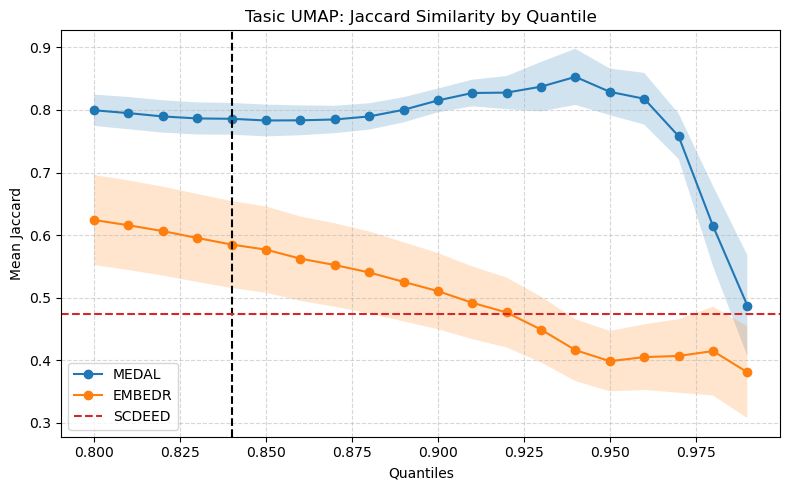

In [40]:
j3_medal_teachers, core_medal_teachers = zip(*[
    jaccard_curve(per_sample_recon_medal_all_umap[n], np.linspace(0.8, 0.99, 20))
    for n in umap_param_sweep
])
j3_medal_teachers = np.array(j3_medal_teachers)
core_medal_teachers = np.array(core_medal_teachers)

j3_embedr_teachers, core_embedr_teachers = zip(*[
    jaccard_curve(per_sample_recon_embedr_all_umap[n], np.linspace(0.8, 0.99, 20))
    for n in umap_param_sweep
])
j3_embedr_teachers = np.array(j3_embedr_teachers)
core_embedr_teachers = np.array(core_embedr_teachers)

j3_scdeed_teachers = [np.logical_and.reduce([per_sample_recon_scdeed_all_umap[n][s] for s in [0, 2, 10]]).sum() /
                      np.logical_or.reduce([per_sample_recon_scdeed_all_umap[n][s] for s in [0, 2, 10]]).sum()
                     for n in umap_param_sweep]

quantiles = np.linspace(0.8, 0.99, 20)

results = {
    "MEDAL": j3_medal_teachers,
    "EMBEDR": j3_embedr_teachers,
}

fig, ax = plt.subplots(figsize=(8, 5))

for label, data in results.items():          
    means = data.mean(axis=0)      
    se = data.std(axis=0) / np.sqrt(data.shape[0])  

    ax.plot(quantiles,means, marker='o', label=label)
    ax.fill_between(quantiles, means - se, means + se, alpha=0.2)

ax.axvline(x = quantiles[4], ls = '--', c ='black')
ax.axhline(y = np.mean(j3_scdeed_teachers), ls = '--', label='SCDEED', color='tab:red')
ax.set_xlabel("Quantiles")
ax.set_ylabel("Mean Jaccard")
ax.set_title("Tasic UMAP: Jaccard Similarity by Quantile")
ax.legend()
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

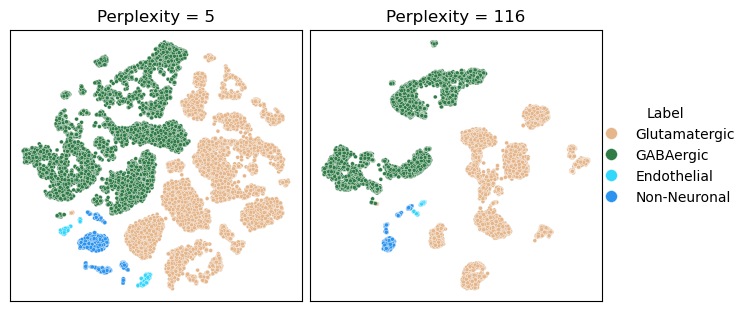

In [41]:
fig, axes = plt.subplots(1,2, figsize=(6, 3), constrained_layout=True)
axes_flat = axes.flatten()
teacher_embed = {}
teacher_embed['embedr_1'] = np.load(Path(PATH_PREFIX) / f"drd_data/embeddings2/tasic_tsne_5_0_train.npy")
teacher_embed['embedr_2'] = np.load(Path(PATH_PREFIX) / f"drd_data/embeddings2/tasic_tsne_116_10_train.npy")
sns.scatterplot(x=teacher_embed['embedr_1'][:, 0], y=teacher_embed['embedr_1'][:, 1], 
                ax=axes_flat[0], s=8, hue=y_class, palette = tasic_palette_class,
                legend=False, rasterized=True)
axes_flat[0].set_title("Perplexity = 5")
sns.scatterplot(x=teacher_embed['embedr_2'][:, 0], y=teacher_embed['embedr_2'][:, 1], 
                ax=axes_flat[1], s=8, hue=y_class, palette = tasic_palette_class,
                legend=True, rasterized=True)
axes_flat[1].set_title("Perplexity = 116")
handles, labels = axes_flat[1].get_legend_handles_labels()
axes_flat[1].legend_.remove()
fig.legend(handles, labels, loc='center', bbox_to_anchor=(1.1, 0.5), 
           frameon=False, title='Label', ncol=1, fontsize=10, markerscale=3, title_fontsize=10)
for ax in axes_flat:
    ax.set_xticks([])
    ax.set_yticks([])

In [43]:
# by_k_tsne = pd.read_csv('mnist_by_k_tsne.csv', index_col=0)
# by_k_tsne = by_k_tsne.sort_values(by = ['k', "method"])
# groups = by_k_tsne["k"].unique()
# methods = by_k_tsne["method"].unique()

# color_palette = {
#     f"EMBEDR_SEED1 ({embedr_1_best})": "#08306b",
#     f"EMBEDR_SEED2 ({embedr_2_best})": '#204479',
#     f"EMBEDR_SEED3 ({embedr_3_best})": '#395988',
#     f"PCS_SEED1 ({pcs_ss_1_best})": "#1a5c2a",
#     f"PCS_SEED2 ({pcs_ss_2_best})": "#306c3f",
#     f"PCS_SEED3 ({pcs_ss_3_best})": "#477c54",
#     f"MEDAL_SEED1 ({medal_1_best})":   "#e6a817",
#     f"MEDAL_SEED2 ({medal_2_best})": "#e8b02e",
#     f"MEDAL_SEED3 ({medal_3_best})": "#ebb945",
#     f"SCDEED_SEED1 ({scdeed_1_best})":  "#d62728",
#     f"SCDEED_SEED2 ({scdeed_2_best})": "#da3c3d",
#     f"SCDEED_SEED3 ({scdeed_3_best})": "#de5252",
# }

# group_gap = 1.2        
# x = np.arange(len(groups)) * group_gap
# z = 1.96  # 95% CI

# delta = 0.05  # vertical spacing between methods
# offsets = (np.arange(len(methods)) - (len(methods) - 1) / 2) * delta

# plt.figure(figsize=(15, 5))

# for i, m in enumerate(methods):
#     sub = by_k_tsne[by_k_tsne["method"] == m].set_index("k").loc[groups]
#     plt.errorbar(x=x + offsets[i], y=sub["train_tw_mean"], yerr=z * sub["train_tw_stderr"], fmt="o", capsize=3, label=m, color=color_palette[m])

# plt.xticks(x, groups)
# plt.ylabel("Trustworthiness")
# plt.xlabel("k")
# plt.ylim(0.5, 1)

# # Adjust legend
# # handles, labels = plt.gca().get_legend_handles_labels()
# # label_map = {"EMBEDR": 'EMBEDR (5)*', 'PCS_SS': 'PCS_SS (5)*', 'SCDEED': 'SCDEED (341)***', 'MEDAL': 'MEDAL (793)**'}
# # plt.legend(handles, [label_map[l] for l in labels], frameon=False)
# plt.legend()

# plt.grid(True, alpha=0.3)
# plt.title("MNIST-tSNE Train Trustworthiness", fontweight='bold')
# plt.tight_layout()
# plt.show()


In [ ]:
# pcs_ss_1_best, pcs_ss_2_best, pcs_ss_3_best = 5, 1846, 341
# scdeed_1_best, scdeed_2_best, scdeed_3_best = 341, 1846, 793
# embedr_1_best, embedr_2_best, embedr_3_best = 5, 5, 5
# medal_1_best, medal_2_best, medal_3_best = 793, 793, 793

# teacher_embed = {}
# teacher_embed['scdeed_1'] = np.load(Path(PATH_PREFIX) / f"MEDAL/comparisons/data/mnist_train_tsne_{scdeed_1_best}_0_train_pc6.npy")
# teacher_embed['scdeed_2'] = np.load(Path(PATH_PREFIX) / f"MEDAL/comparisons/data/mnist_train_tsne_{scdeed_2_best}_2_train_pc6.npy")
# teacher_embed['scdeed_3'] = np.load(Path(PATH_PREFIX) / f"MEDAL/comparisons/data/mnist_train_tsne_{scdeed_3_best}_10_train_pc6.npy")

# teacher_embed['medal_1'] = np.load(Path(PATH_PREFIX) / f"drd_data/embeddings2/mnist_tsne_{medal_1_best}_0_train.npy")
# teacher_embed['medal_2'] = np.load(Path(PATH_PREFIX) / f"drd_data/embeddings2/mnist_tsne_{medal_2_best}_10_train.npy")
# teacher_embed['medal_3'] = np.load(Path(PATH_PREFIX) / f"drd_data/embeddings2/mnist_tsne_{medal_3_best}_2_train.npy")

# teacher_embed['embedr_1'] = np.load(Path(PATH_PREFIX) / f"drd_data/embeddings/mnist_tsne_{embedr_1_best}_0_train_embedr.npy").squeeze(0)
# teacher_embed['embedr_2'] = np.load(Path(PATH_PREFIX) / f"drd_data/embeddings/mnist_tsne_{embedr_2_best}_10_train_embedr.npy").squeeze(0)
# teacher_embed['embedr_3'] = np.load(Path(PATH_PREFIX) / f"drd_data/embeddings/mnist_tsne_{embedr_3_best}_2_train_embedr.npy").squeeze(0)

# teacher_embed['pcs_ss_1'] = np.load(Path(PATH_PREFIX) / f"drd_data/embeddings/mnist_tsne_{pcs_ss_1_best}_0_train_pcs.npy")
# teacher_embed['pcs_ss_2'] = np.load(Path(PATH_PREFIX) / f"drd_data/embeddings/mnist_tsne_{pcs_ss_2_best}_2_train_pcs.npy")
# teacher_embed['pcs_ss_3'] = np.load(Path(PATH_PREFIX) / f"drd_data/embeddings/mnist_tsne_{pcs_ss_3_best}_10_train_pcs.npy")

In [66]:
from utils import evaluate_methods
seed_list = [0,2,10]
scdeed_best = {
    "tsne": {0: 341, 2: 1846, 10: 793},
    "umap": {0: 499, 2: 5,    10: 5}
}
embedr_best = {
    "tsne": {0: 5,   2: 5,   10: 5},
    "umap": {0: 499, 2: 499, 10: 499}
}
pcs_best = {
    "tsne": {0: 5,   2: 1846,   10: 793},
}
medal_best = {
    "tsne": {0: 793, 2: 793, 10: 793},
    "umap": {0: 49,  2: 18,  10: 18}
}

teacher_embed = {}
for s in seed_list:
    teacher_embed[f'scdeed_{s}'] = np.load(Path(PATH_PREFIX) / f"MEDAL/comparisons/data/mnist_train_tsne_{scdeed_best['tsne'][s]}_{s}_train_pc6.npy")
    teacher_embed[f'medal_{s}'] = np.load(Path(PATH_PREFIX) / f"drd_data/embeddings2/mnist_tsne_{medal_best['tsne'][s]}_{s}_train.npy")
    teacher_embed[f'embedr_{s}'] = np.load(Path(PATH_PREFIX) / f"drd_data/embeddings/mnist_tsne_{embedr_best['tsne'][s]}_{s}_train_embedr.npy").squeeze(0)
    teacher_embed[f'pcs_{s}'] = np.load(Path(PATH_PREFIX) / f"drd_data/embeddings/mnist_tsne_{pcs_best['tsne'][s]}_{s}_train_pcs.npy")
    
umap_acc_df = pd.concat([
    evaluate_methods(
        {
            f"EMBEDR_SEED1 ({embedr_best['tsne'][0]})":  (teacher_embed["embedr_0"], None),
            f"EMBEDR_SEED2 ({embedr_best['tsne'][2]})":  (teacher_embed["embedr_2"], None),
            f"EMBEDR_SEED3 ({embedr_best['tsne'][10]})":  (teacher_embed["embedr_10"], None),
            f"SCDEED_SEED1 ({scdeed_best['tsne'][0]})": (teacher_embed["scdeed_0"], None),
            f"SCDEED_SEED2 ({scdeed_best['tsne'][2]})": (teacher_embed["scdeed_2"], None),
            f"SCDEED_SEED3 ({scdeed_best['tsne'][10]})": (teacher_embed["scdeed_10"], None),
            f'PCS_SEED1 ({pcs_best["tsne"][0]})':  (teacher_embed["pcs_0"], None),
            f'PCS_SEED2 ({pcs_best["tsne"][2]})':  (teacher_embed["pcs_2"], None),
            f'PCS_SEED3 ({pcs_best["tsne"][10]})':  (teacher_embed["pcs_10"], None),
        },
        y_og, None, cv = 5, random_state = 0, return_estimators = True)[0],
    evaluate_methods(
        {
            f"MEDAL_SEED1 ({medal_best['tsne'][0]})":  (teacher_embed["medal_0"], None), 
            f"MEDAL_SEED2 ({medal_best['tsne'][2]})":  (teacher_embed["medal_2"], None), 
            f"MEDAL_SEED3 ({medal_best['tsne'][10]})":  (teacher_embed["medal_10"], None), 
        },
        y, None, cv = 5, random_state = 0, return_estimators = True)[0],
])

umap_acc_df

,train_accuracy,train_accuracy_std,train_macro_f1,train_macro_f1_std,test_accuracy,test_accuracy_std,test_macro_f1,test_macro_f1_std
method,,,,,,,,
EMBEDR_SEED1 (5),0.999875,0.000153,0.999866,0.000164,0.942250,0.006808,0.941474,0.006573
EMBEDR_SEED2 (5),0.999844,0.000140,0.999834,0.000150,0.942125,0.004305,0.941065,0.004492
EMBEDR_SEED3 (5),0.999844,0.000099,0.999833,0.000108,0.939500,0.004633,0.938649,0.004791
PCS_SEED1 (5),0.999844,0.000099,0.999830,0.000108,0.939375,0.003558,0.938488,0.003551
PCS_SEED3 (793),0.999938,0.000077,0.999934,0.000081,0.893000,0.006065,0.891083,0.006337
PCS_SEED2 (1846),0.999875,0.000062,0.999871,0.000065,0.765000,0.012924,0.759641,0.012863
SCDEED_SEED1 (341),0.999844,0.000140,0.999841,0.000142,0.740250,0.011643,0.734154,0.011720
SCDEED_SEED3 (793),0.999906,0.000077,0.999898,0.000083,0.679750,0.012258,0.670833,0.012029
SCDEED_SEED2 (1846),0.999969,0.000062,0.999971,0.000058,0.585500,0.007920,0.573425,0.007446


In [71]:
from utils import evaluate_methods
seed_list = [0,2,10]
scdeed_best = {
    "tsne": {0: 341, 2: 1846, 10: 793},
    "umap": {0: 499, 2: 5,    10: 5}
}
embedr_best = {
    "tsne": {0: 5,   2: 5,   10: 5},
    "umap": {0: 499, 2: 499, 10: 499}
}
pcs_best = {
    "tsne": {0: 5,   2: 1846,   10: 793},
}
medal_best = {
    "tsne": {0: 793, 2: 793, 10: 793},
    "umap": {0: 49,  2: 18,  10: 18}
}

teacher_embed = {}

teacher_embed[f'medal_1'] = np.load(Path(PATH_PREFIX) / f"drd_data/embeddings2/mnist_tsne_793_0_train.npy")
teacher_embed[f'medal_2'] = np.load(Path(PATH_PREFIX) / f"drd_data/embeddings2/mnist_tsne_5_0_train.npy")
from sklearn.ensemble import RandomForestClassifier as RFC
rfc1 = RFC(random_state=0)
rfc1.fit(teacher_embed[f'medal_1'], y)
print(f"train acc: {rfc1.score(teacher_embed[f'medal_1'], y):.3f}, test acc: {rfc1.score(, y_test):.3f}")
rfc2 = RFC(random_state=0)
rfc2.fit(teacher_embed[f'medal_2'], y)
print(f"train acc: {rfc2.score(teacher_embed[f'medal_1'], y):.3f}, test acc: {rfc2.score(X_test, y_test):.3f}")


ValueError: X has 784 features, but RandomForestClassifier is expecting 2 features as input.

In [113]:
from utils import evaluate_methods

teacher_embed = {}
for i, n in enumerate(np.unique(np.logspace(np.log10(5), np.log10(500), 15).astype(int))):
    teacher_embed[f'embedr_{i}'] = (np.load(Path(PATH_PREFIX) / f"drd_data/embeddings/mnist_umap_{n}_0.1_0_train_embedr.npy").squeeze(0), None)

umap_acc_df = pd.concat([
    evaluate_methods(
        teacher_embed,
        y_og, None, cv = 5, random_state = 0, return_estimators = True)[0],
#     evaluate_methods(
#         {
#             f"MEDAL_SEED1 ({medal_1_best})":  (teacher_embed["medal_1"], None), 
#             f"MEDAL_SEED2 ({medal_2_best})":  (teacher_embed["medal_2"], None), 
#             f"MEDAL_SEED3 ({medal_3_best})":  (teacher_embed["medal_3"], None), 
#         },
#         y, None, cv = 5, random_state = 0, return_estimators = True)[0],
])

umap_acc_df

,train_accuracy,train_accuracy_std,train_macro_f1,train_macro_f1_std,test_accuracy,test_accuracy_std,test_macro_f1,test_macro_f1_std
method,,,,,,,,
embedr_0,0.999906,0.000077,0.999900,0.000082,0.925500,0.006748,0.924595,0.006502
embedr_1,0.999875,0.000117,0.999869,0.000123,0.924250,0.005280,0.922976,0.005229
embedr_3,0.999875,0.000062,0.999871,0.000065,0.922625,0.006643,0.921566,0.006538
embedr_2,0.999812,0.000117,0.999801,0.000128,0.920875,0.006933,0.919872,0.006602
embedr_5,0.999844,0.000099,0.999838,0.000102,0.915625,0.004953,0.914308,0.004552
embedr_4,0.999781,0.000212,0.999774,0.000216,0.915625,0.006034,0.914092,0.005829
embedr_6,0.999812,0.000182,0.999811,0.000183,0.903000,0.004172,0.901250,0.003456
embedr_8,0.999875,0.000062,0.999870,0.000065,0.879125,0.006157,0.875589,0.006486
embedr_7,0.999844,0.000140,0.999838,0.000144,0.863875,0.001992,0.858004,0.002674


In [133]:
# TASIC
X_og, X_test, y_og, y_test = load_and_split("tasic", test_size=0.2, seed=0, labels=True)
X, X_val, y, y_val = train_test_split(X_og, y_og, test_size=0.2, random_state=0)
from utils import evaluate_methods

seed_list = [0,2,10]
scdeed_best = {
    "tsne": {0: 53, 2: 2729, 10: 53},
    "umap": {0: 2000, 2: 2000,    10: 18}
}
embedr_best = {
    "tsne": {0: 2729,   2: 2729,   10: 2729},
    "umap": {0: 2000, 2: 271, 10: 271}
}
pcs_best = {
    "tsne": {0: 5,   2: 5,   10: 5},
}
medal_best = {
    "tsne": {0: 6000, 2: 6000, 10: 6000},
    "umap": {0: 5,  2: 5,  10: 9}
}

teacher_embed = {}
teacher_embed = {}
for s in seed_list:
    teacher_embed[f'scdeed_{s}'] = np.load(Path(PATH_PREFIX) / f"MEDAL/comparisons/data/tasic_train_tsne_{scdeed_best['tsne'][s]}_{s}_train_pc4.npy")
    teacher_embed[f'medal_{s}'] = np.load(Path(PATH_PREFIX) / f"drd_data/embeddings2/tasic_tsne_{medal_best['tsne'][s]}_{s}_train.npy")
    teacher_embed[f'embedr_{s}'] = np.load(Path(PATH_PREFIX) / f"drd_data/embeddings/tasic_tsne_{embedr_best['tsne'][s]}_{s}_train_embedr.npy").squeeze(0)
    teacher_embed[f'pcs_{s}'] = np.load(Path(PATH_PREFIX) / f"drd_data/embeddings/tasic_tsne_{pcs_best['tsne'][s]}_{s}_train_pcs.npy")

tsne_acc_df = pd.concat([
    evaluate_methods(
        {
            f"EMBEDR_SEED1 ({embedr_best['tsne'][0]})":  (teacher_embed["embedr_0"], None),
            f"EMBEDR_SEED2 ({embedr_best['tsne'][2]})":  (teacher_embed["embedr_2"], None),
            f"EMBEDR_SEED3 ({embedr_best['tsne'][10]})":  (teacher_embed["embedr_10"], None),
            f"SCDEED_SEED1 ({scdeed_best['tsne'][0]})": (teacher_embed["scdeed_0"], None),
            f"SCDEED_SEED2 ({scdeed_best['tsne'][2]})": (teacher_embed["scdeed_2"], None),
            f"SCDEED_SEED3 ({scdeed_best['tsne'][10]})": (teacher_embed["scdeed_10"], None),
            f'PCS_SEED1 ({pcs_best["tsne"][0]})':  (teacher_embed["pcs_0"], None),
            f'PCS_SEED2 ({pcs_best["tsne"][2]})':  (teacher_embed["pcs_2"], None),
            f'PCS_SEED3 ({pcs_best["tsne"][10]})':  (teacher_embed["pcs_10"], None),
        },
        y_og, None, cv = 5, random_state = 0, return_estimators = True)[0],
    evaluate_methods(
        {
            f"MEDAL_SEED1 ({medal_best['tsne'][0]})":  (teacher_embed["medal_0"], None), 
            f"MEDAL_SEED2 ({medal_best['tsne'][2]})":  (teacher_embed["medal_2"], None), 
            f"MEDAL_SEED3 ({medal_best['tsne'][10]})":  (teacher_embed["medal_10"], None), 
        },
        y, None, cv = 5, random_state = 0, return_estimators = True)[0],
])

tsne_acc_df.sort_values('test_accuracy')

/home/bnc2119/.conda/envs/medal/lib/python3.10/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(
/home/bnc2119/.conda/envs/medal/lib/python3.10/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(
/home/bnc2119/.conda/envs/medal/lib/python3.10/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(
/home/bnc2119/.conda/envs/medal/lib/python3.10/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(
/home/bnc2119/.conda/envs/medal/lib/python3.10/site-packages/sklearn/metrics/_classification.py:99: UserWarning: The number of unique classes is greater

,train_accuracy,train_accuracy_std,train_macro_f1,train_macro_f1_std,test_accuracy,test_accuracy_std,test_macro_f1,test_macro_f1_std
method,,,,,,,,
SCDEED_SEED2 (2729),1.000000,0.000000,1.000000,0.000000,0.379073,0.004457,0.224862,0.005685
SCDEED_SEED1 (53),0.999961,0.000032,0.999953,0.000039,0.492732,0.009301,0.352214,0.011206
SCDEED_SEED3 (53),0.999948,0.000049,0.999928,0.000085,0.495303,0.005486,0.347972,0.008251
MEDAL_SEED2 (6000),0.999967,0.000040,0.999907,0.000129,0.788586,0.005683,0.700006,0.008041
MEDAL_SEED3 (6000),0.999934,0.000033,0.999854,0.000129,0.791538,0.002864,0.697976,0.008846
MEDAL_SEED1 (6000),0.999967,0.000040,0.999926,0.000128,0.798098,0.005645,0.704418,0.006520
EMBEDR_SEED2 (2729),0.999948,0.000049,0.999731,0.000423,0.848350,0.005040,0.766439,0.004284
EMBEDR_SEED1 (2729),0.999987,0.000026,0.999986,0.000029,0.848612,0.005077,0.768266,0.004287
EMBEDR_SEED3 (2729),0.999974,0.000032,0.999972,0.000035,0.854647,0.002542,0.783148,0.009495


In [149]:
X_og, X_test, y_og, y_test = load_and_split("mnist", test_size=0.2, seed=0, labels=True)
X, X_val, y, y_val = train_test_split(X_og, y_og, test_size=0.2, random_state=0)
tsne_res_dict_teacher_seeds = []
for s in range(1):
    for ts in [0, 2, 10]:
        for n in np.unique(np.logspace(np.log10(5), np.log10(2000), 10).astype(int)):
            teacher_embed = np.load(Path(PATH_PREFIX) / f"drd_data/embeddings2/hydra_umap_{n}_0.1_{ts}_train.npy")
            student = load_trained_ae(Path(PATH_PREFIX) / f"drd_data/tmp_results/chkpt_teacher_seed/hydra/medal_tsne2_{n}_tc{s}_{ts}_ckpts/final.pt",
                                    input_dim=784,
                                    hidden_dims=[512, 512, 512, 512],
                                    latent_dim=2, batchnorm=True)

            student_recon, student_embed = student(torch.tensor(X, dtype=torch.float32))
            train_distill = np.mean((teacher_embed - student_embed.detach().numpy()) ** 2)
            if train_distill < 1e-5:
                train_recon = np.mean((student_recon.detach().numpy() - X)**2)
                tsne_res_dict_teacher_seeds.append({"n_neighbors": n, "recon_loss": train_recon, "split": "Train", "teacher_seed": ts, "seed": s})

                x_val_recon, _ = student(torch.tensor(X_val, dtype=torch.float32))
                val_recon = np.mean((x_val_recon.detach().numpy() - X_val)**2)
                tsne_res_dict_teacher_seeds.append({"n_neighbors": n, "recon_loss": val_recon, "split": "Val", "teacher_seed": ts, "seed": s})

                x_test_recon, _ = student(torch.tensor(X_test, dtype=torch.float32))
                test_recon = np.mean((x_test_recon.detach().numpy() - X_test)**2)
                tsne_res_dict_teacher_seeds.append({"n_neighbors": n, "recon_loss": test_recon, "split": "Test", "teacher_seed": ts, "seed": s})
            else:
                print(f"Skipping param {perp} seed {s} due to distillation loss {train_distill}")

/tmp/ipykernel_21037/1041672765.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sd = torch.load(ckpt_path, map_location="cpu")


loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded par

FileNotFoundError: [Errno 2] No such file or directory: '/share/ctn/users/bnc2119/drd_data/tmp_results/chkpt_teacher_seed/hydra/medal_tsne2_5_tc1_2_ckpts/final.pt'

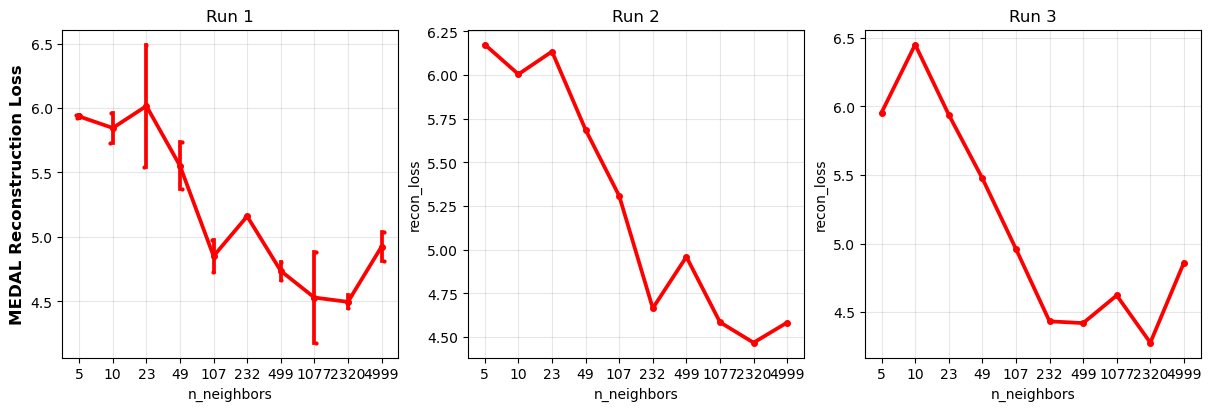

In [150]:
tsne_teacher_seeds = pd.DataFrame(tsne_res_dict_teacher_seeds).set_index('teacher_seed')
tsne_teacher_seeds = tsne_teacher_seeds.loc[tsne_teacher_seeds.split == "Val"]
fig, axes = plt.subplots(1, 3, figsize=(12,4), constrained_layout=True)
axes_flat = axes.flatten()
# 1st row 
sns.pointplot(data=tsne_teacher_seeds.loc[0, :], x='n_neighbors', y='recon_loss', color='red', markersize=3, ax = axes_flat[0])
sns.stripplot(data=tsne_teacher_seeds.loc[0, :], x='n_neighbors', y='recon_loss', color='red', size=3, ax = axes_flat[0])
axes_flat[0].set_title("Run 1")

sns.pointplot(data=tsne_teacher_seeds.loc[2, :], x='n_neighbors', y='recon_loss', color='red', markersize=3, ax = axes_flat[1])
sns.stripplot(data=tsne_teacher_seeds.loc[2, :], x='n_neighbors', y='recon_loss', color='red', size=3, ax = axes_flat[1])
axes_flat[1].set_title("Run 2")

sns.pointplot(data=tsne_teacher_seeds.loc[10, :], x='n_neighbors', y='recon_loss', color='red', markersize=3, ax = axes_flat[2])
sns.stripplot(data=tsne_teacher_seeds.loc[10, :], x='n_neighbors', y='recon_loss', color='red', size=3, ax = axes_flat[2])
axes_flat[2].set_title("Run 3")
axes_flat[0].set_ylabel("MEDAL Reconstruction Loss", fontsize=12, fontweight='bold')
for ax in axes_flat:
    ax.grid(True, alpha=0.3)

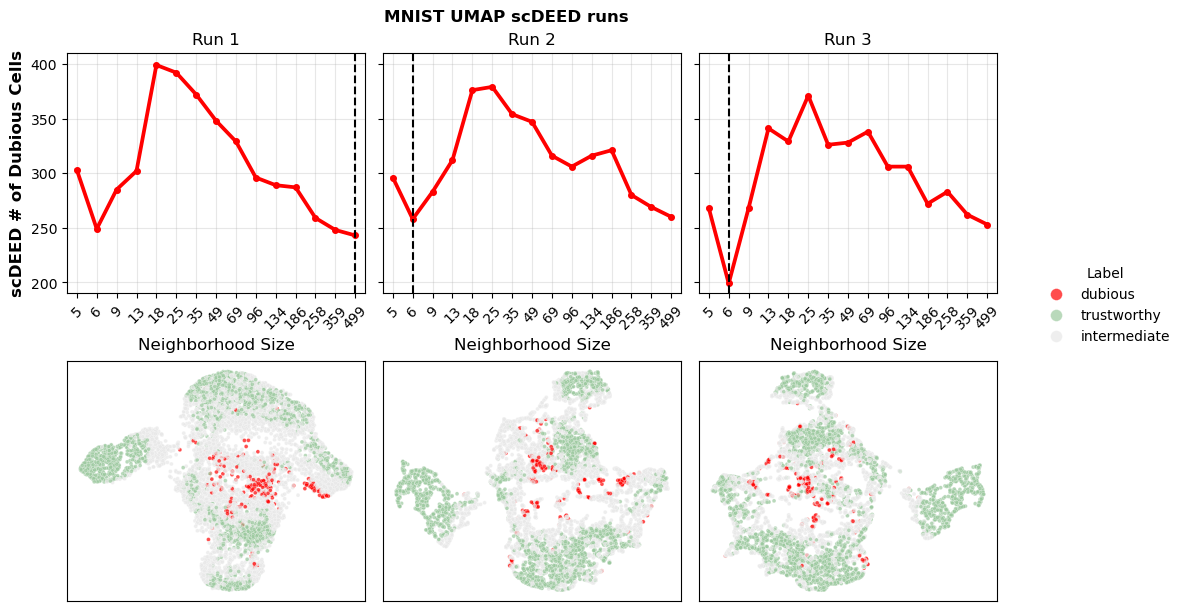

In [23]:
# showing that scdeed is inconsistent
methods = ['scdeed_1', 'scdeed_2', 'scdeed_3']
scdeed_1_best, scdeed_2_best, scdeed_3_best = 499, 6, 5
teacher_embed = {}
teacher_embed['scdeed_1'] = np.load(Path(PATH_PREFIX) / f"MEDAL/comparisons/data/mnist_train_umap_{scdeed_1_best}_0.1_0_train_pc6.npy")
teacher_embed['scdeed_2'] = np.load(Path(PATH_PREFIX) / f"MEDAL/comparisons/data/mnist_train_umap_{scdeed_2_best}_0.1_0_train_2_pc6.npy")
teacher_embed['scdeed_3'] = np.load(Path(PATH_PREFIX) / f"MEDAL/comparisons/data/mnist_train_umap_{scdeed_3_best}_0.1_0_train_3_pc6.npy")

scdeed_df1 = pd.read_csv(Path(PATH_PREFIX) / "MEDAL/comparisons/results_scdeed_umap/seed0/umap_best_mnist_train_full_results.csv", index_col=0)
per_sample_scdeed1 = split_scdeed_labels(scdeed_df1, scdeed_1_best)['label']
scdeed_df2 = pd.read_csv(Path(PATH_PREFIX) / "MEDAL/comparisons/results_scdeed_umap/seed0_2/umap_best_mnist_train_full_results.csv", index_col=0)
per_sample_scdeed2 = split_scdeed_labels(scdeed_df2, scdeed_2_best)['label']
scdeed_df3 = pd.read_csv(Path(PATH_PREFIX) / "MEDAL/comparisons/results_scdeed_umap/seed0_3/umap_best_mnist_train_full_results.csv", index_col=0)
per_sample_scdeed3 = split_scdeed_labels(scdeed_df3, scdeed_3_best)['label']
palette_scdeed = {'dubious': 'red', 'intermediate': '#e8e8e8', 'trustworthy': "#9cc99f"}

scdeed_analysis1 = pd.read_csv(Path(PATH_PREFIX) / 'MEDAL/comparisons/results_scdeed_umap/seed0/umap_best_mnist_train_num_dubious.csv')
umap_argmin = scdeed_analysis1['number_dubious_cells'].idxmin()
argmin_position1 = scdeed_analysis1.index.tolist().index(umap_argmin)
scdeed_analysis2 = pd.read_csv(Path(PATH_PREFIX) / 'MEDAL/comparisons/results_scdeed_umap/seed0_2/umap_best_mnist_train_num_dubious.csv')
umap_argmin = scdeed_analysis2['number_dubious_cells'].idxmin()
argmin_position2 = scdeed_analysis2.index.tolist().index(umap_argmin)
scdeed_analysis3 = pd.read_csv(Path(PATH_PREFIX) / 'MEDAL/comparisons/results_scdeed_umap/seed0_3/umap_best_mnist_train_num_dubious.csv')
umap_argmin = scdeed_analysis3['number_dubious_cells'].idxmin()
argmin_position3 = scdeed_analysis3.index.tolist().index(umap_argmin)

cmap = sns.color_palette("BuGn", as_cmap=True)
fig, axes = plt.subplots(2,3, figsize=(10, 6), constrained_layout=True)
axes_flat = axes.flatten()

# 1st row 
sns.pointplot(data=scdeed_analysis1, x='n_neighbors', y='number_dubious_cells', color='red', markersize=3, ax = axes_flat[0])
axes_flat[0].axvline(x = argmin_position1, ls = '--', c ='black')
axes_flat[0].set_title("Run 1")

sns.pointplot(data=scdeed_analysis2, x='n_neighbors', y='number_dubious_cells', color='red', markersize=3, ax = axes_flat[1])
axes_flat[1].axvline(x = argmin_position2, ls = '--', c ='black')
axes_flat[1].set_title("Run 2")

sns.pointplot(data=scdeed_analysis3, x='n_neighbors', y='number_dubious_cells', color='red', markersize=3, ax = axes_flat[2])
axes_flat[2].axvline(x = argmin_position3, ls = '--', c ='black')
axes_flat[2].set_title("Run 3")
axes_flat[0].set_ylabel("scDEED # of Dubious Cells", fontsize=12, fontweight='bold')

axes_flat[1].set_ylabel("")
axes_flat[2].set_ylabel("")

# 2nd row 
sns.scatterplot(x=teacher_embed['scdeed_1'][:, 0], y=teacher_embed['scdeed_1'][:, 1], 
                ax=axes_flat[3], s=8, hue = per_sample_scdeed1, palette = palette_scdeed, legend=True, alpha=0.7)
sns.scatterplot(x=teacher_embed['scdeed_2'][:, 0], y=teacher_embed['scdeed_2'][:, 1], 
                ax=axes_flat[4], s=8, hue = per_sample_scdeed2, palette = palette_scdeed, legend=False, alpha=0.7)
sns.scatterplot(x=teacher_embed['scdeed_3'][:, 0], y=teacher_embed['scdeed_3'][:, 1], 
                ax=axes_flat[5], s=8, hue = per_sample_scdeed3, palette = palette_scdeed, legend=False, alpha=0.7)
# axes_flat[3].set_ylabel(f"UMAP(n_neighbors={scdeed_1_best})")

# Legend
handles, labels = axes_flat[3].get_legend_handles_labels()
axes_flat[3].legend_.remove()
fig.legend(handles, labels, loc='center', bbox_to_anchor=(1.1, 0.5), 
           frameon=False, title='Label', ncol=1, fontsize=10, markerscale=3, title_fontsize=10)

for i in [0,1,2]:
    axes_flat[i].grid(True, alpha=0.3)
    axes_flat[i].set_ylim(190, 410)
    axes_flat[i].set_xlabel("Neighborhood Size", fontsize=12)
    plt.setp(axes_flat[i].get_xticklabels(), rotation=45, ha='center')

for ax in axes_flat[3:]:
    ax.set_yticks([])
    ax.set_xticks([])
axes_flat[1].set_yticklabels([])
axes_flat[2].set_yticklabels([])

fig.suptitle("MNIST UMAP scDEED runs", fontweight='bold')
plt.show()

In [188]:
X, X_test, y, y_test = load_and_split("astro", test_size=0.2, seed=0, labels=True)
X, _, y, _ = train_test_split(X, y, test_size=0.2, random_state=0)
pd.Series(y_test).value_counts().mean()

np.float64(82.25)

In [231]:
# plt.figure(figsize=(10,7))
mnist_by_k_tsne = pd.read_csv('tasic_by_k_tsne_all_methods.csv', index_col=0)
# mnist_by_k_tsne.reset_index(names='k', inplace=True)
mnist_by_k_tsne[['triplet_accuracy', 'spearman_rho', 'method', 'lcmc_mean']].drop_duplicates().sort_values('triplet_accuracy')
# mnist_by_k_tsne = mnist_by_k_tsne.loc[mnist_by_k_tsne.k <= 50]
# mnist_by_k_tsne.loc[:, 'lcmc_mean'] = mnist_by_k_tsne.groupby(['method', 'split'])['lcmc'].transform('mean')
# mnist_by_k_tsne.reset_index(names='k', inplace=True)
# mnist_by_k_tsne = mnist_by_k_tsne.loc[mnist_by_k_tsne.k <= 50].
# sns.pointplot(data = mnist_by_k_tsne[(mnist_by_k_tsne.split=='Test') & (mnist_by_k_tsne.method.isin(['MEDAL_49', 'MEDAL_499']) )], x = 'k', hue='method', y='lcmc', markersize=2, alpha = 0.5)

,triplet_accuracy,spearman_rho,method,lcmc_mean
10,0.5872,0.309098,PCS_SEED0 (5),0.454391
10,0.7964,0.707899,EMBEDR_SEED0 (2729),0.486008
10,0.7968,0.737975,SCDEED_SEED0 (2729),0.557916
10,0.7986,0.696011,MEDAL_SEED0 (6000),0.479837


<Axes: xlabel='k', ylabel='lcmc'>

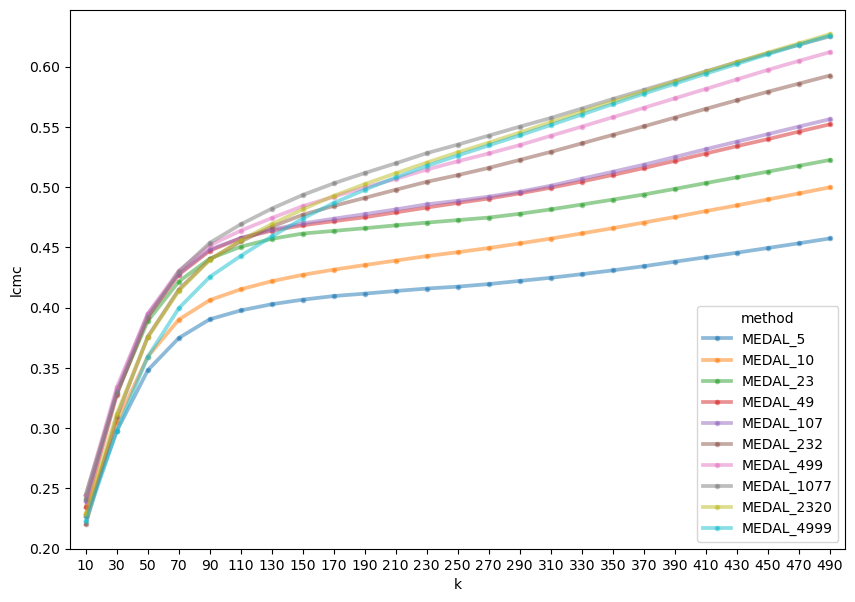

In [133]:
plt.figure(figsize=(10,7))
mnist_by_k_tsne = pd.read_csv('hydra_by_k_tsne_medal.csv', index_col=0)
# mnist_by_k_tsne.reset_index(names='k', inplace=True)
mnist_by_k_tsne = mnist_by_k_tsne.loc[mnist_by_k_tsne.k <= 500]
sns.pointplot(data = mnist_by_k_tsne[mnist_by_k_tsne.split == "Test"], x = 'k', hue='method', y='lcmc', markersize=2, alpha = 0.5)

In [130]:
mnist_by_k_tsne[['triplet_accuracy', 'spearman_rho', 'method', 'lcmc_mean']].drop_duplicates().sort_values('lcmc_mean')

,triplet_accuracy,spearman_rho,method,lcmc_mean
500,0.6362,0.408390,PCS_SEED0 (5),0.464584
250,0.7446,0.576355,EMBEDR_SEED0 (4999),0.652584
0,0.6630,0.367291,MEDAL_SEED0 (1077),0.657489
750,0.7838,0.706554,SCDEED_SEED0 (4999),0.865456


In [93]:
mnist_by_k_tsne = pd.read_csv('mnist_by_k_tsne_medal.csv', index_col=0)
mnist_by_k_tsne.
mnist_by_k_tsne[['triplet_accuracy', 'spearman_rho', 'method', 'lcmc_mean', 'split']].drop_duplicates().sort_values('lcmc_mean')

,triplet_accuracy,spearman_rho,method,lcmc_mean,split
0,0.6208,0.367855,MEDAL_5,0.461253,Train
400,0.6092,0.337860,MEDAL_11,0.482287,Train
800,0.6196,0.390551,MEDAL_27,0.485037,Train
1200,0.6490,0.461957,MEDAL_62,0.498818,Train
600,0.6316,0.335899,MEDAL_11,0.502496,Test
200,0.6330,0.366170,MEDAL_5,0.502552,Test
1600,0.6410,0.451870,MEDAL_146,0.505895,Train
1000,0.6364,0.381493,MEDAL_27,0.509723,Test
2800,0.6960,0.633559,MEDAL_1846,0.513717,Train
2000,0.6448,0.487577,MEDAL_341,0.517068,Train


In [104]:
hydra_by_k_tsne = pd.read_csv('hydra_by_k_tsne_all_methods.csv', index_col=0)
hydra_by_k_tsne.reset_index(names='k', inplace=True)
hydra_by_k_tsne[['triplet_accuracy', 'spearman_rho', 'method', 'lcmc_mean']].drop_duplicates().sort_values('method')

,triplet_accuracy,spearman_rho,method,lcmc_mean
250,0.7446,0.576355,EMBEDR_SEED0 (4999),0.652584
0,0.6630,0.367291,MEDAL_SEED0 (1077),0.657489
500,0.6362,0.408390,PCS_SEED0 (5),0.464584
750,0.7838,0.706554,SCDEED_SEED0 (4999),0.865456


<Axes: xlabel='k', ylabel='lcmc'>

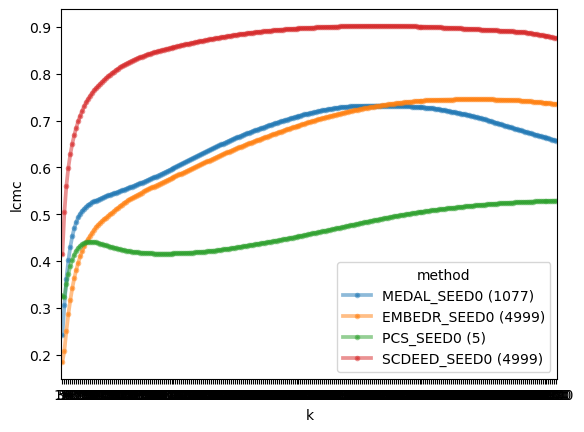

In [106]:
sns.pointplot(data = hydra_by_k_tsne, x = 'k', hue='method', y='lcmc', markersize=2, alpha = 0.5)

In [109]:
mnist_by_k_umap = pd.read_csv('mnist_by_k_umap_medal.csv', index_col=0)
mnist_by_k_umap[['triplet_accuracy', 'spearman_rho', 'method', 'lcmc_mean', 'split']].drop_duplicates().sort_values('lcmc_mean')
# sns.pointplot(data = mnist_by_k_umap[mnist_by_k_umap.split == "Test"], x = 'k', hue='method', y='lcmc', markersize=2, alpha = 0.5)

,triplet_accuracy,spearman_rho,method,lcmc_mean,split
5600,0.6146,0.298513,MEDAL_499,0.467911,Train
0,0.5912,0.287198,MEDAL_5,0.469415,Train
400,0.5872,0.255114,MEDAL_6,0.474352,Train
5200,0.6042,0.279793,MEDAL_359,0.477090,Train
200,0.6020,0.264116,MEDAL_5,0.480131,Test
600,0.5906,0.236841,MEDAL_6,0.483820,Test
4800,0.6060,0.283510,MEDAL_258,0.483840,Train
800,0.6076,0.339474,MEDAL_9,0.484550,Train
4000,0.6170,0.328010,MEDAL_134,0.487095,Train
1200,0.6014,0.292980,MEDAL_13,0.488317,Train


In [112]:
hydra_by_k_tsne = pd.read_csv('hydra_by_k_tsne_medal.csv', index_col=0)
hydra_by_k_tsne[['triplet_accuracy', 'spearman_rho', 'method', 'lcmc_mean', 'split']].drop_duplicates().sort_values('lcmc_mean')


,triplet_accuracy,spearman_rho,method,lcmc_mean,split
0,0.6534,0.451793,MEDAL_5,0.504708,Train
500,0.6988,0.505686,MEDAL_10,0.551268,Train
1000,0.6836,0.494383,MEDAL_23,0.567506,Train
1500,0.7068,0.495413,MEDAL_49,0.605993,Train
2000,0.6806,0.432683,MEDAL_107,0.609576,Train
2500,0.6596,0.365492,MEDAL_232,0.634747,Train
3000,0.6560,0.352454,MEDAL_499,0.646173,Train
3500,0.6630,0.367291,MEDAL_1077,0.657489,Train
4000,0.6762,0.414648,MEDAL_2320,0.659916,Train
4500,0.7686,0.643916,MEDAL_4999,0.664662,Train


<Axes: xlabel='k', ylabel='lcmc'>

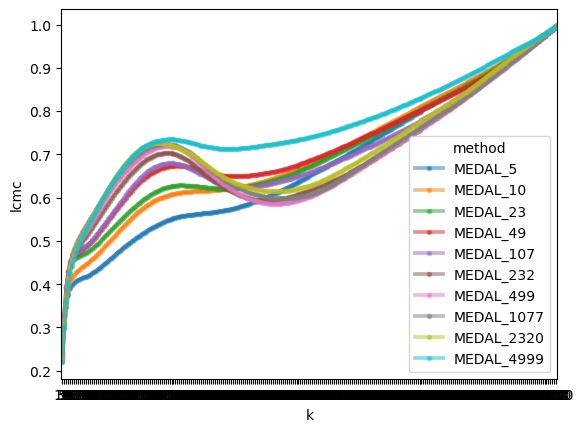

In [114]:
sns.pointplot(data = hydra_by_k_tsne[hydra_by_k_tsne.split == "Test"], x = 'k', hue='method', y='lcmc', markersize=2, alpha = 0.5)

In [101]:
hydra_by_k_tsne

,k,triplet_accuracy,spearman_rho,lcmc,lcmc_mean,method,split
0,10,0.6534,0.451793,0.337375,0.504708,MEDAL_5,Train
1,30,0.6534,0.451793,0.340908,0.504708,MEDAL_5,Train
2,50,0.6534,0.451793,0.369390,0.504708,MEDAL_5,Train
3,70,0.6534,0.451793,0.393480,0.504708,MEDAL_5,Train
4,90,0.6534,0.451793,0.412805,0.504708,MEDAL_5,Train
...,...,...,...,...,...,...,...
4995,4910,0.7486,0.615951,0.983691,0.762707,MEDAL_4999,Test
4996,4930,0.7486,0.615951,0.986372,0.762707,MEDAL_4999,Test
4997,4950,0.7486,0.615951,0.989199,0.762707,MEDAL_4999,Test
4998,4970,0.7486,0.615951,0.992308,0.762707,MEDAL_4999,Test


In [111]:
from sklearn.ensemble import RandomForestClassifier as RFC
X, X_test, y, y_test = load_and_split("mnist", test_size=0.2, seed=0, labels=True)
X, _, y, _ = train_test_split(X, y, test_size=0.2, random_state=0)
mnist_umap_res_dict = []

for n in np.unique(np.logspace(np.log10(5), np.log10(500), 15).astype(int)):
    teacher_embed = np.load(Path(PATH_PREFIX) / f"drd_data/embeddings2/mnist_umap_{n}_0.1_0_train.npy")
    student = load_trained_ae(Path(PATH_PREFIX) / f"drd_data/tmp_results/chkpt_teacher_seed/mnist/medal_umap2_{n}_0.1_tc0_0_ckpts/final.pt",
            input_dim=784,
            hidden_dims=[512, 512, 512, 512], 
            latent_dim=2, activation=torch.nn.SELU, batchnorm=False)

    student_recon, student_embed = student(torch.tensor(X, dtype=torch.float32))
    train_distill = np.mean((teacher_embed - student_embed.detach().numpy()) ** 2)
    if train_distill < 1e-5:
        _, x_test_embed = student(torch.tensor(X_test, dtype=torch.float32))
        rfc1 = RFC(random_state=0)
        rfc1.fit(teacher_embed, y)
        print(f"train acc: {rfc1.score(teacher_embed, y):.3f}, test acc: {rfc1.score(x_test_embed.detach().numpy(), y_test):.3f}")
       
    
    else:
        print(f"Skipping param {n} seed {s} due to distillation loss {train_distill}")

/tmp/ipykernel_3553/1041672765.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sd = torch.load(ckpt_path, map_location="cpu")


loaded params: 20 | missing=0 | unexpected=0
train acc: 1.000, test acc: 0.866
loaded params: 20 | missing=0 | unexpected=0


/tmp/ipykernel_3553/1041672765.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sd = torch.load(ckpt_path, map_location="cpu")


train acc: 1.000, test acc: 0.870
loaded params: 20 | missing=0 | unexpected=0


/tmp/ipykernel_3553/1041672765.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sd = torch.load(ckpt_path, map_location="cpu")


...

train acc: 1.000, test acc: 0.738
loaded params: 20 | missing=0 | unexpected=0


/tmp/ipykernel_3553/1041672765.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sd = torch.load(ckpt_path, map_location="cpu")


train acc: 1.000, test acc: 0.722
loaded params: 20 | missing=0 | unexpected=0


/tmp/ipykernel_3553/1041672765.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sd = torch.load(ckpt_path, map_location="cpu")


train acc: 1.000, test acc: 0.706
